## Библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression


## Загрузка данных

In [2]:
df = pd.read_excel('data/data.xlsx').drop(columns='Unnamed: 0')

Оценим общее состояния данных.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [4]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


## Оценка данных:
Количество записей: 1 001.
Количество столбцов: 213.


Оценим количество пропусков, количество столбцов, где все значения 0, и колличестов колонок , шде признак кодирован 0 или 1.

## Анализ пропусков, нулевых значений и бинарных признаков

Вспомогательные функции для ропусков, нулевых значений и бинарных признаков

In [5]:

def show_nans(df):
    #Ищем пропуски
    print('='*60)
    print('поиск пропусков')
    emptys = []
    for col in df.columns:
        if df[col].isna().sum()>0:
            print(f'В колонке {col} есть  {df[col].isna().sum()} пропусков.')
            emptys.append(col)
    print('поиск завершен')
    print('='*60)
    return emptys

def show_nullls(df, tolerance):
    #Ищем колонки, где есть процент значений с большим числом 0
    print('='*60)
    print('поиск доли нулевых значений')
    print(f'Пороговое значение равно {tolerance}')
    empty_cols = []
    for col in df.columns:
        zeroes=100*len(df.loc[df[col] == 0])/len(df) 
        if zeroes>=tolerance:
            #print(f'В колонке {col} доля нулей  {(zeroes):.2f} %.')
            empty_cols.append(col)
    print('='*60)
    print(f'Разреженный колонок {len(empty_cols)}.')
    return empty_cols

def find_binary_columns(df):
    #Ищем колонки где значения строго 1 или 2
    binary_columns = []
    for col in df.columns:
        if len(df.loc[df[col]==1])+(len(df.loc[df[col]==0]))==len(df) and df[col].isna().sum()==0 and len(df[col].value_counts())==2:
            binary_columns.append(col)
    print(f'колонок со значениями 0 и 1: {len(binary_columns)}')
    return binary_columns

In [6]:
#Ищем пропуски
empty_cols=show_nans(df)

поиск пропусков
В колонке MaxPartialCharge есть  3 пропусков.
В колонке MinPartialCharge есть  3 пропусков.
В колонке MaxAbsPartialCharge есть  3 пропусков.
В колонке MinAbsPartialCharge есть  3 пропусков.
В колонке BCUT2D_MWHI есть  3 пропусков.
В колонке BCUT2D_MWLOW есть  3 пропусков.
В колонке BCUT2D_CHGHI есть  3 пропусков.
В колонке BCUT2D_CHGLO есть  3 пропусков.
В колонке BCUT2D_LOGPHI есть  3 пропусков.
В колонке BCUT2D_LOGPLOW есть  3 пропусков.
В колонке BCUT2D_MRHI есть  3 пропусков.
В колонке BCUT2D_MRLOW есть  3 пропусков.
поиск завершен


In [7]:
 #Ищем колонки, где есть процент значений с большим числом 0
_ =show_nullls(df,99)

поиск доли нулевых значений
Пороговое значение равно 99
Разреженный колонок 33.


In [8]:
#Ищем колонки где значения строго 1 или 2
_ =find_binary_columns(df)

колонок со значениями 0 и 1: 30


## Пропуски



In [9]:
df[df['MaxPartialCharge'].isna()][empty_cols]

,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df[df['MaxPartialCharge'].isna()]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,250.175,...,1,0,0,0,0,0,0,0,0,0


Пропуски
Обнаружено три строки с пропусками.  Стратегия заполнения -  заполнение медианной.
Нулевые колонки
В массиве данных был обнаружен ряд колонок, которые в большой степени до 99% заполнены нулями. Их мы просто удалим.
Бинарные признаки
Ряд колонок заполнены строго 0 или 1, эти колонки будут исключены из численного преобразования.

## Целевая пременная
### IC50

<Axes: xlabel='IC50, mM', ylabel='Count'>

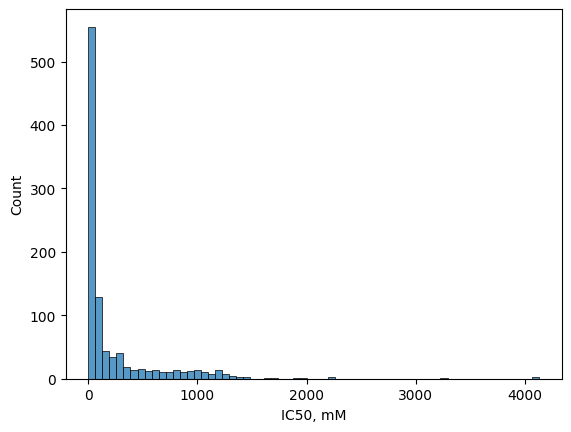

In [11]:
sns.histplot(df['IC50, mM'])

<Axes: ylabel='IC50, mM'>

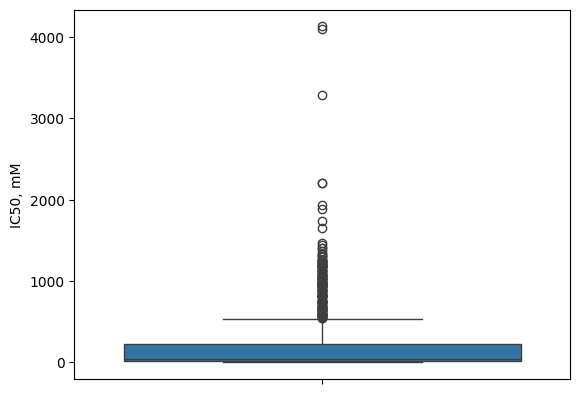

In [12]:
sns.boxplot(df['IC50, mM'])

В преременной есть выбросы

Создадим признак для крассификации 

In [13]:
print(f'Значение медианы для IC50, mM {df['IC50, mM'].median():.3f}')
df['IC50_classification'] = 0
IC50_median = df['IC50, mM'].median()
df.loc[df['IC50, mM']>IC50_median,'IC50_classification']=1


Значение медианы для IC50, mM 46.585


/tmp/ipykernel_35960/2236037398.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IC50_classification'] = 0


In [14]:
df['IC50_classification'].value_counts()

IC50_classification
0    501
1    500
Name: count, dtype: int64

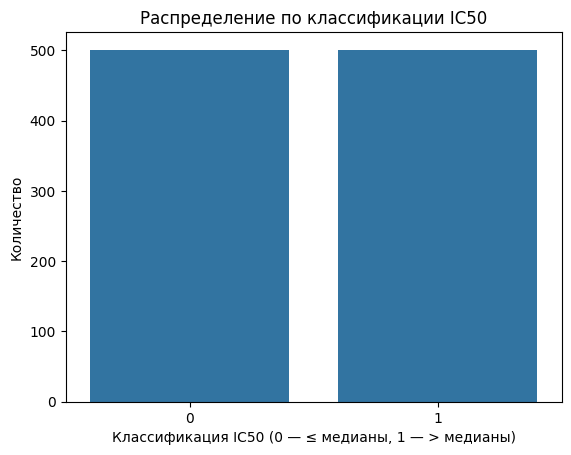

In [15]:
sns.countplot(data=df, x='IC50_classification')
plt.title('Распределение по классификации IC50')
plt.xlabel('Классификация IC50 (0 — ≤ медианы, 1 — > медианы)')
plt.ylabel('Количество')
plt.show()

Классы сбалансированы

### CC50

Значение медианы для CC50, mM, 411.039


/tmp/ipykernel_35960/1292275053.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CC50_classification'] = 0


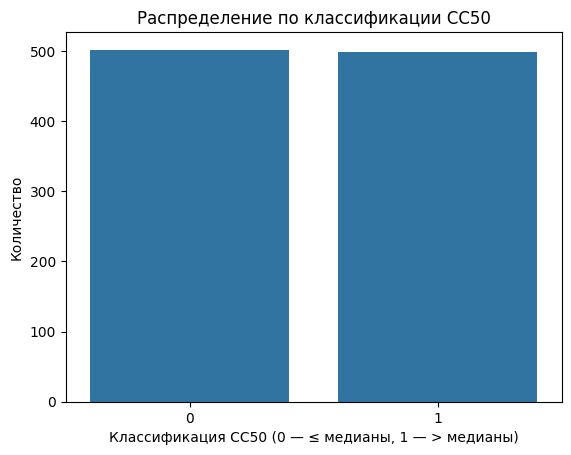

In [16]:
print(f'Значение медианы для CC50, mM, {df['CC50, mM'].median():.3f}')
df['CC50_classification'] = 0
IC50_median = df['CC50, mM'].median()
df.loc[df['CC50, mM']>IC50_median,'CC50_classification']=1

sns.countplot(data=df, x='CC50_classification')
plt.title('Распределение по классификации CC50')
plt.xlabel('Классификация CC50 (0 — ≤ медианы, 1 — > медианы)')
plt.ylabel('Количество')
plt.show()

In [17]:
df['CC50_classification'].value_counts()

CC50_classification
0    502
1    499
Name: count, dtype: int64

### SI

/tmp/ipykernel_35960/281761519.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SI_classification'] = 0


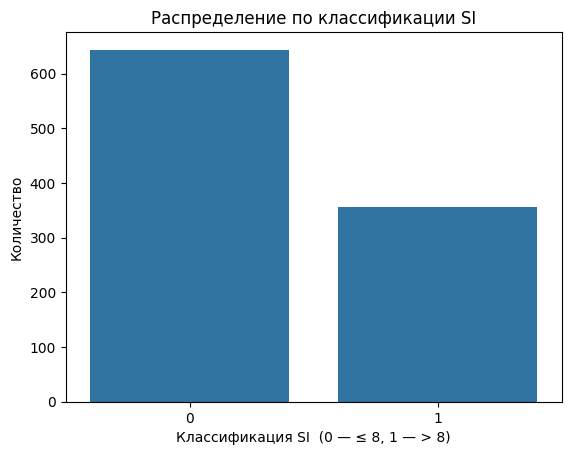

In [18]:
df['SI_classification'] = 0
df.loc[df['SI']>8,'SI_classification']=1

sns.countplot(data=df, x='SI_classification')
plt.title('Распределение по классификации SI')
plt.xlabel('Классификация SI  (0 — ≤ 8, 1 — > 8)')
plt.ylabel('Количество')
plt.show()

### SI_median

/tmp/ipykernel_35960/1579630972.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SI_classification_median'] = 0


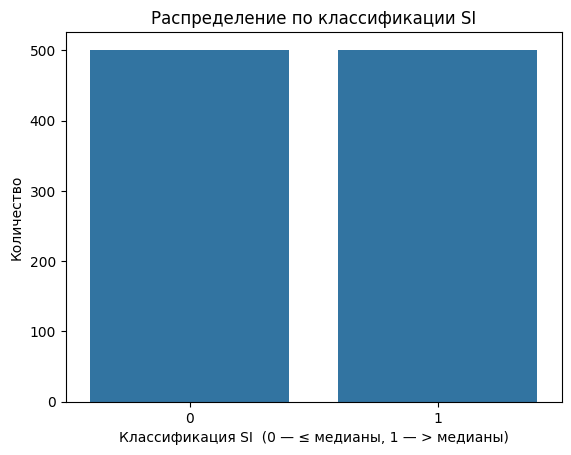

In [19]:
df['SI_classification_median'] = 0
SI_classification_median = df['SI'].median()
df.loc[df['SI']>SI_classification_median,'SI_classification_median']=1

sns.countplot(data=df, x='SI_classification_median')
plt.title('Распределение по классификации SI')
plt.xlabel('Классификация SI  (0 — ≤ медианы, 1 — > медианы)')
plt.ylabel('Количество')
plt.show()

## ВЫбросы
Напишем функцтю по оценке выбросов

In [20]:
def find_cols_with_outliers(df,tolerance):
    print(f'Признаки, где доля выбросов более {tolerance}%.')
    outliers_list = []
    for col in df.columns:
        series = df[col].dropna()
        if len(df[col].value_counts())==2:
            continue

        series = df[col].dropna()
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Обнаружение выбросов
        mask = (series < lower_bound) | (series > upper_bound)
        outliers_qty = mask.sum()
        outliers_prcnt = 100 * outliers_qty / len(series)
        if outliers_prcnt>tolerance:
            outliers_list.append(col)
            print(f'В колонке {col} есть {outliers_prcnt:.1f} % возможных выбросов')
    return outliers_list

tolerance = 20
outliers_list= find_cols_with_outliers(df,tolerance)
print(f'Доля колонок с процентом выбросов более {tolerance}% составялет {len(outliers_list)}')

Признаки, где доля выбросов более 20%.
В колонке Ipc есть 21.8 % возможных выбросов
В колонке PEOE_VSA4 есть 20.5 % возможных выбросов
В колонке VSA_EState10 есть 25.0 % возможных выбросов
В колонке VSA_EState9 есть 24.5 % возможных выбросов
В колонке fr_Al_OH есть 24.3 % возможных выбросов
В колонке fr_allylic_oxid есть 20.9 % возможных выбросов
В колонке fr_amide есть 24.3 % возможных выбросов
В колонке fr_aniline есть 22.2 % возможных выбросов
Доля колонок с процентом выбросов более 20% составялет 8


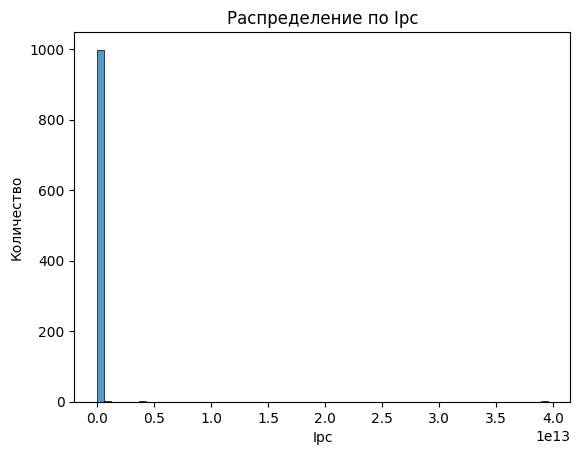

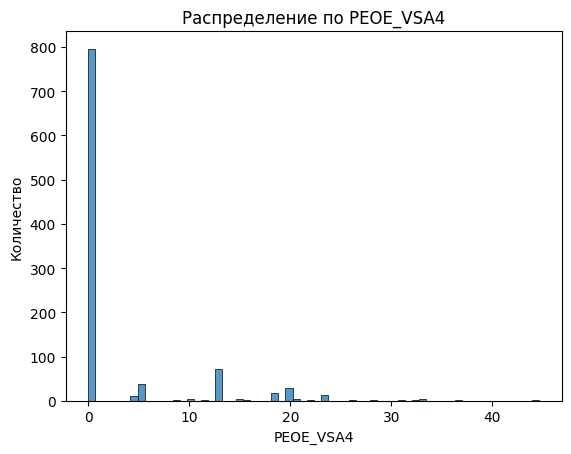

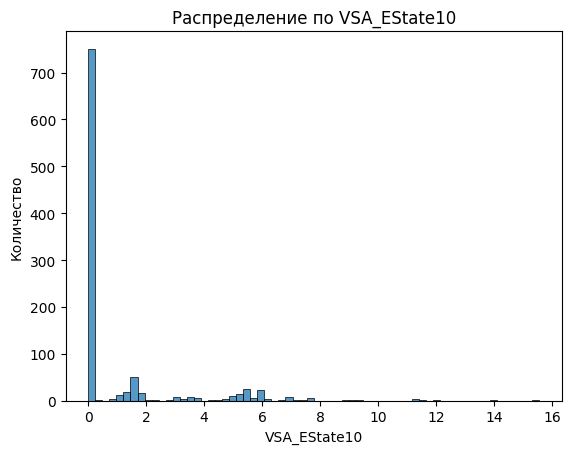

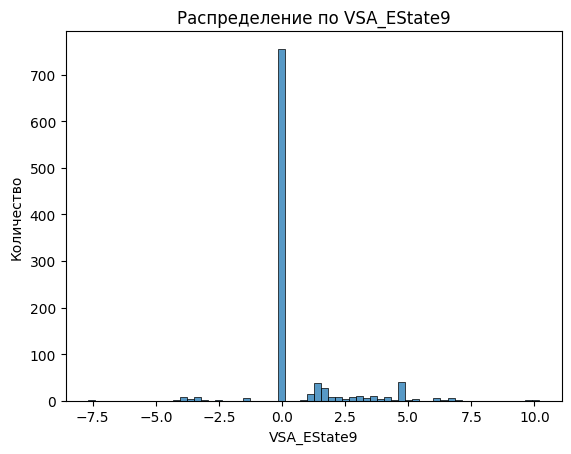

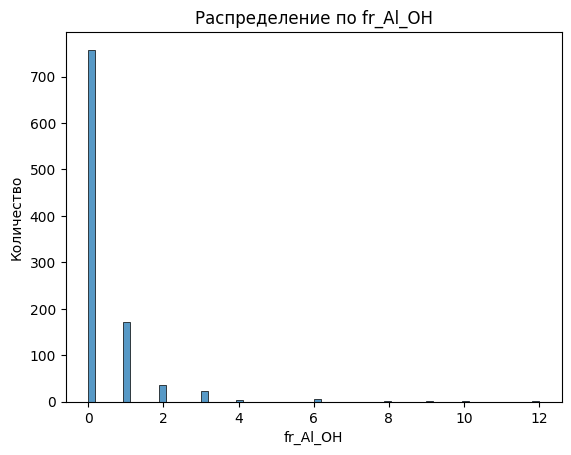

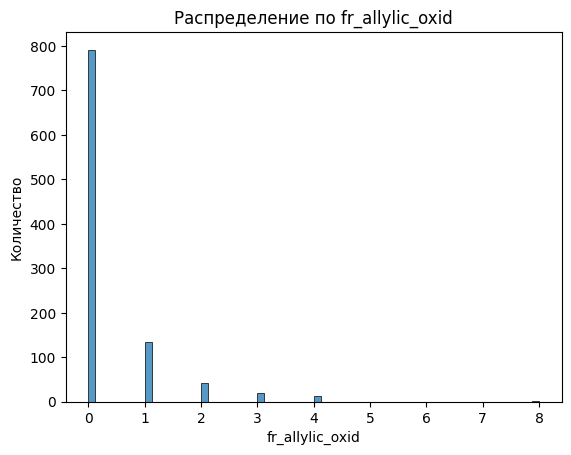

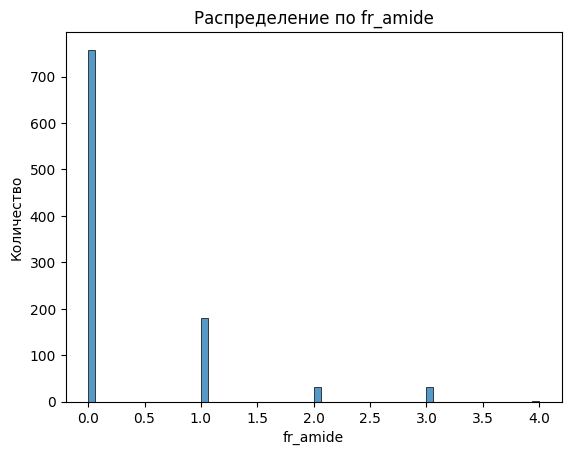

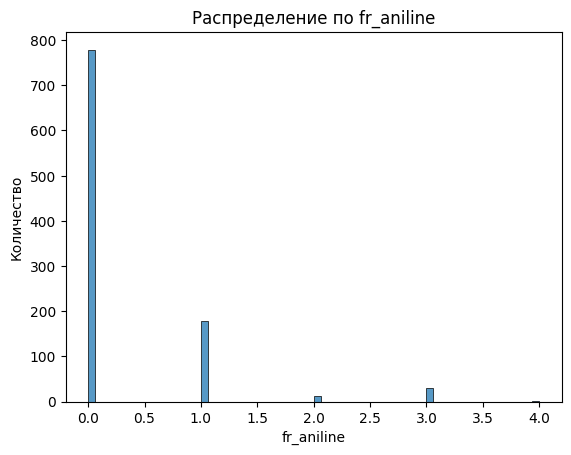

In [21]:
for outlier in outliers_list:
   sns.histplot(x = df[outlier])
   plt.title(f'Распределение по {outlier}')
   plt.xlabel(outlier)
   plt.ylabel('Количество')
   plt.show()

Колонок с большим, более 20 %, выбросов, относительно не велико. После оценки важности признаков, примем решениие, что будем с ними делать. Возможно, эти колонки удасться отбраковать или мы сделаем упор на обучение "деревянных моделей", которые белее усточивы к выбросам.

## Корреляция между признаками
Напишем функцию, которая оценит внутренню корреляцию между признаками.

In [22]:

def corr_feature(df, min_corr_value):
    # Корреляция между признаками
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification','SI_classification_median']
    X = df.drop(columns=targets)
    cor_list = []
    total_list_to_delete = []
    for col in X.columns:
        #print(f'Поиск для {col}')
        corr_target = df.corr(numeric_only=True)[col].drop(col)
        high_corr = corr_target[(corr_target >= min_corr_value) | (corr_target <= -min_corr_value)]
        if len(high_corr) > 0:
            cor_target_dict = {col: list(high_corr.index)}
            cor_list.append(cor_target_dict)
            total_list_to_delete.append(list(high_corr.index))
    total_list_to_delete = set(sum(total_list_to_delete, []))
    return cor_list,total_list_to_delete

cor_list,total_list_to_delete=corr_feature(df, 0.95)
print(cor_list)

[{'MaxAbsEStateIndex': ['MaxEStateIndex']}, {'MaxEStateIndex': ['MaxAbsEStateIndex']}, {'MolWt': ['HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'Chi0', 'Chi0v', 'Chi1', 'Kappa1', 'LabuteASA', 'HeavyAtomCount', 'MolMR']}, {'HeavyAtomMolWt': ['MolWt', 'ExactMolWt', 'NumValenceElectrons', 'Chi0', 'Chi1', 'LabuteASA', 'HeavyAtomCount']}, {'ExactMolWt': ['MolWt', 'HeavyAtomMolWt', 'NumValenceElectrons', 'Chi0', 'Chi0v', 'Chi1', 'Kappa1', 'LabuteASA', 'HeavyAtomCount', 'MolMR']}, {'NumValenceElectrons': ['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Kappa1', 'LabuteASA', 'HeavyAtomCount', 'MolMR']}, {'MaxPartialCharge': ['MinAbsPartialCharge']}, {'MinAbsPartialCharge': ['MaxPartialCharge']}, {'Chi0': ['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'Chi0n', 'Chi0v', 'Chi1', 'Kappa1', 'LabuteASA', 'HeavyAtomCount', 'MolMR']}, {'Chi0n': ['NumValenceElectrons', 'Chi0', 'Chi0v', 'Chi1n', 'Chi1v', 'Kappa1', 'LabuteASA', 'HeavyAtomCou

Мы получили список признаков , которые коррелируют между друг другом и можем их удалить при подготовке обюучения.

## Оценка важности признаков.

### Корреляционный анализ

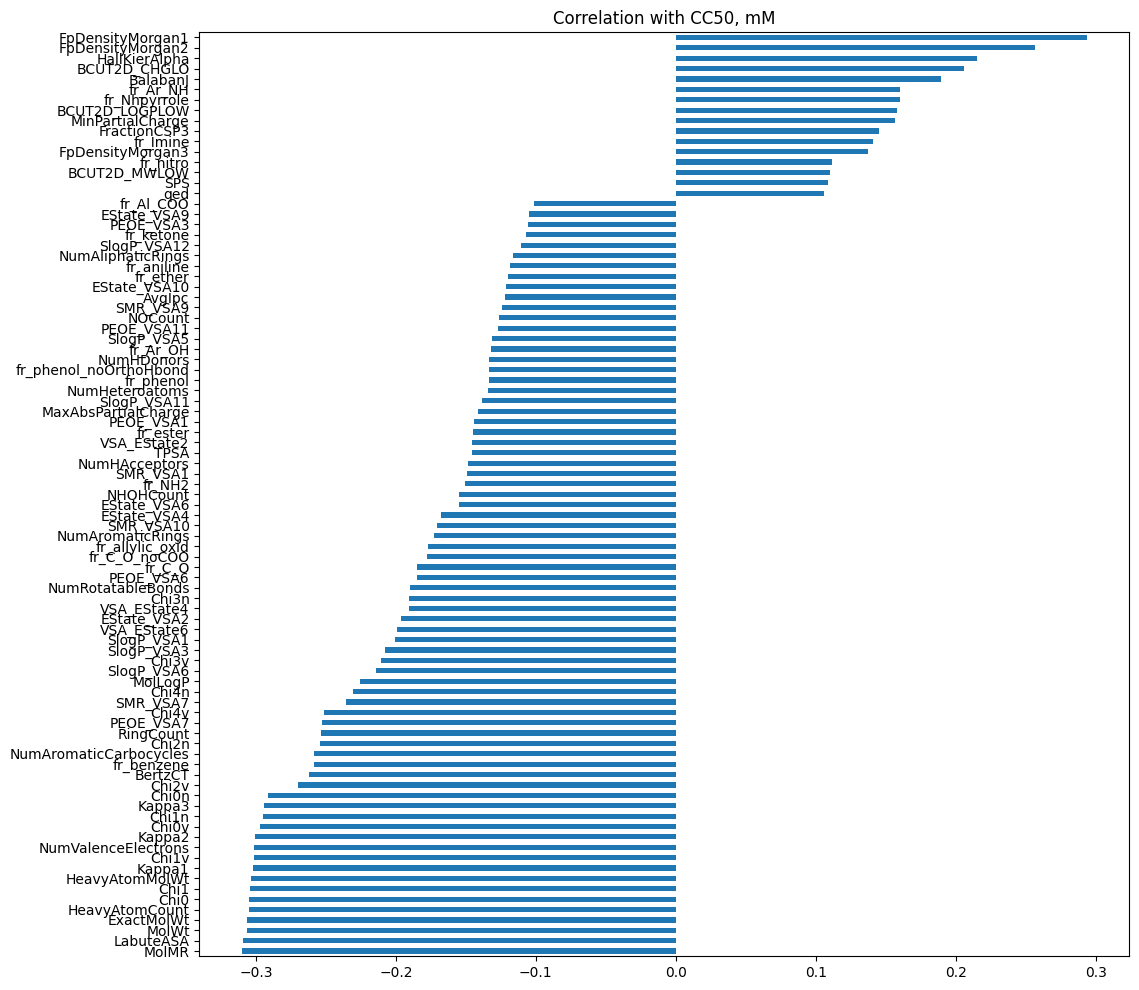

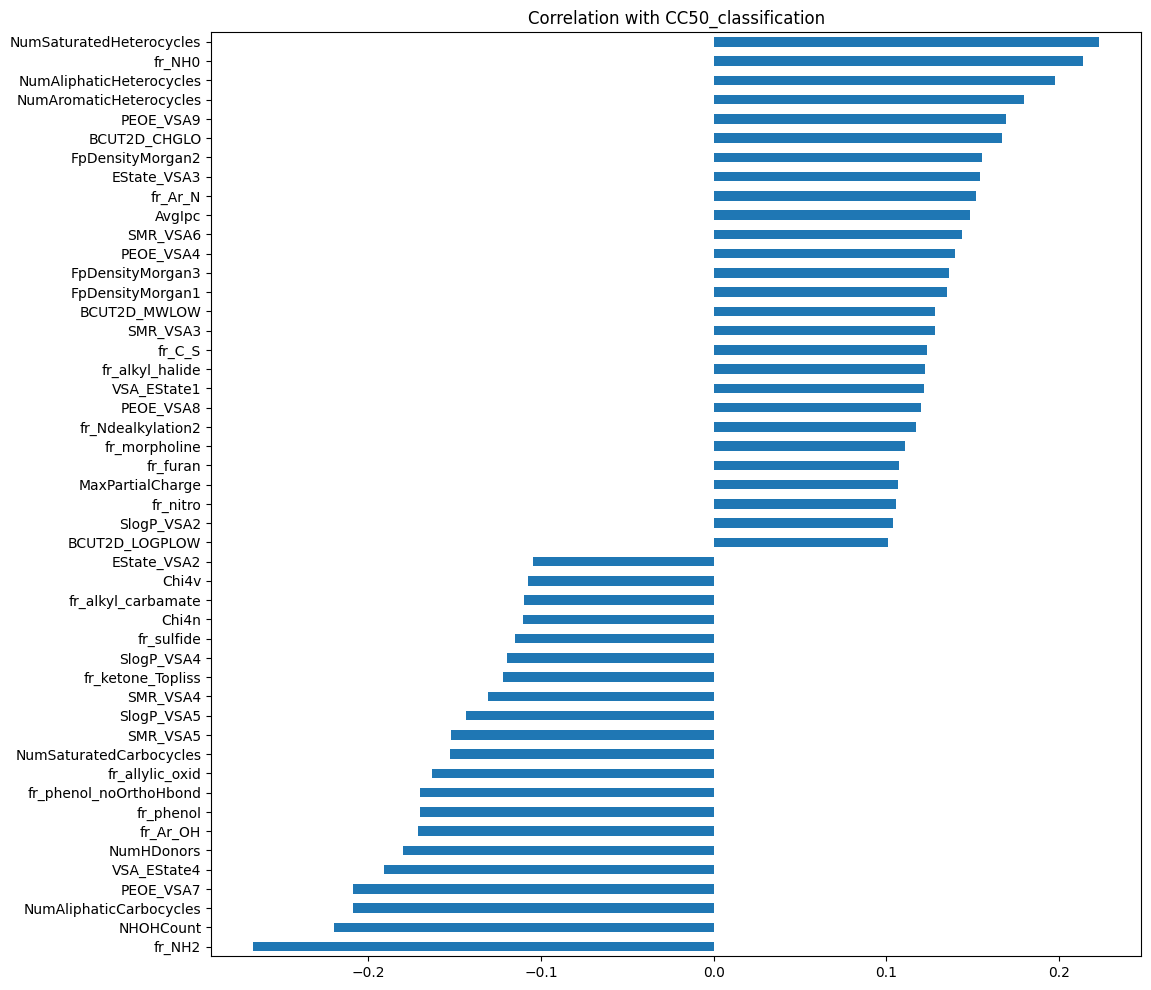

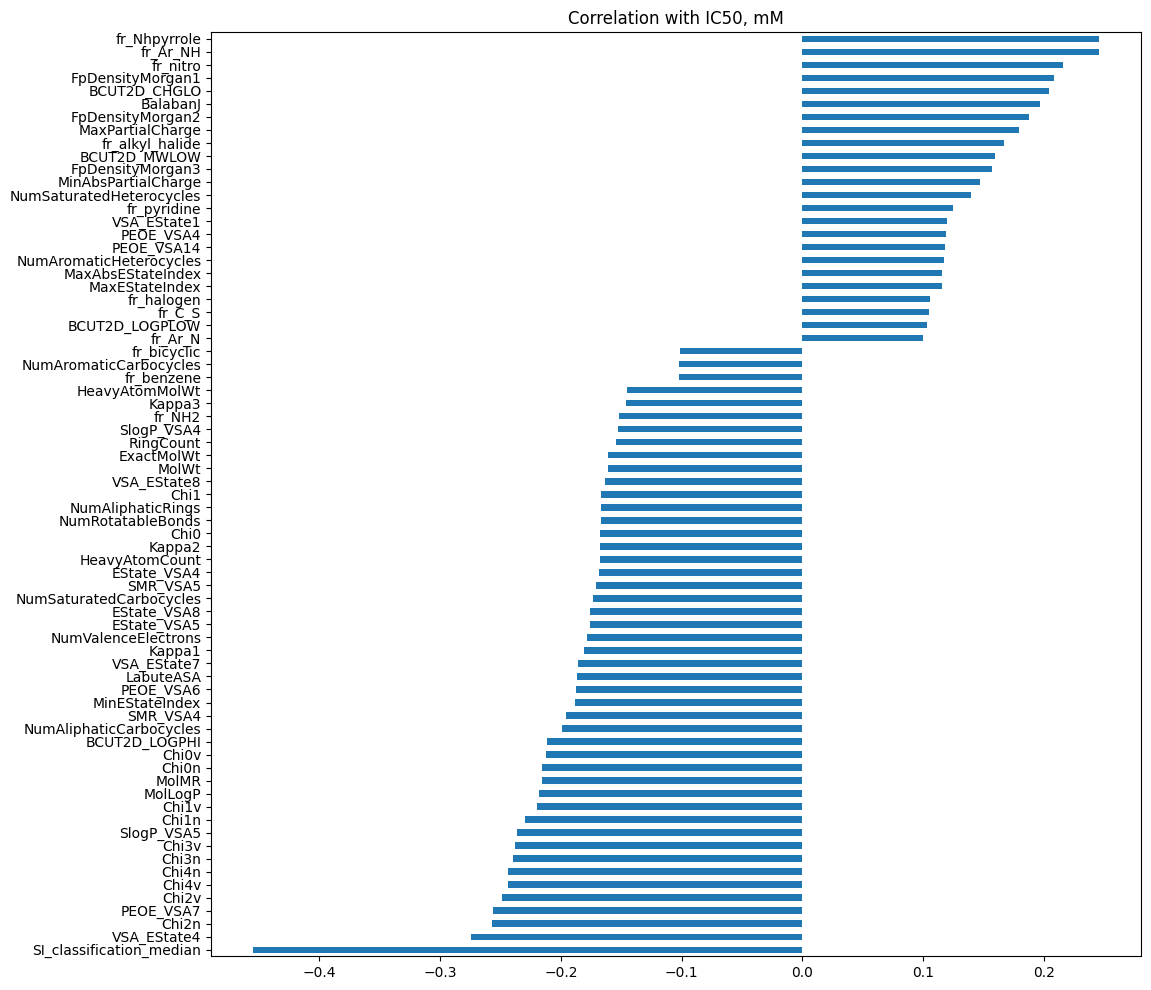

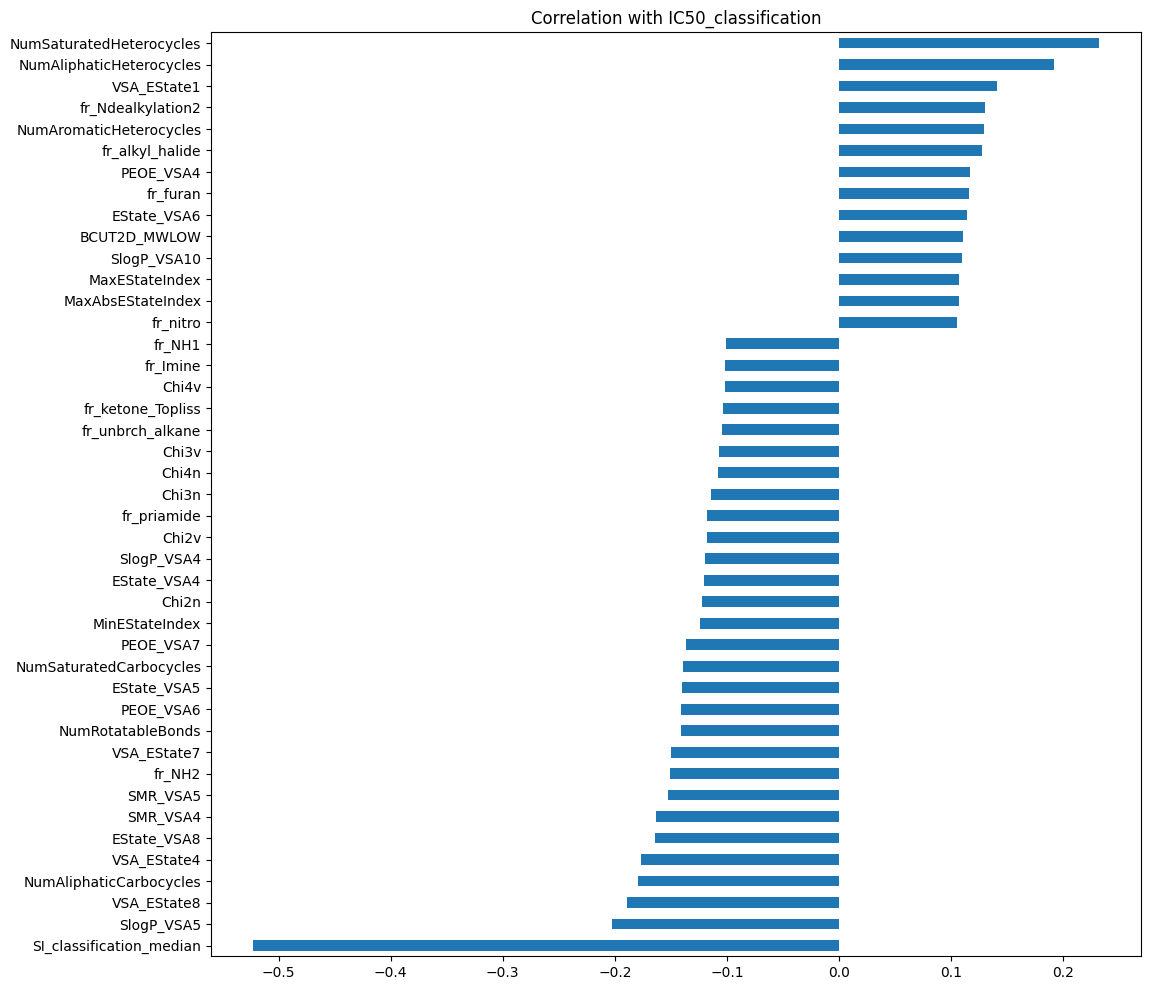

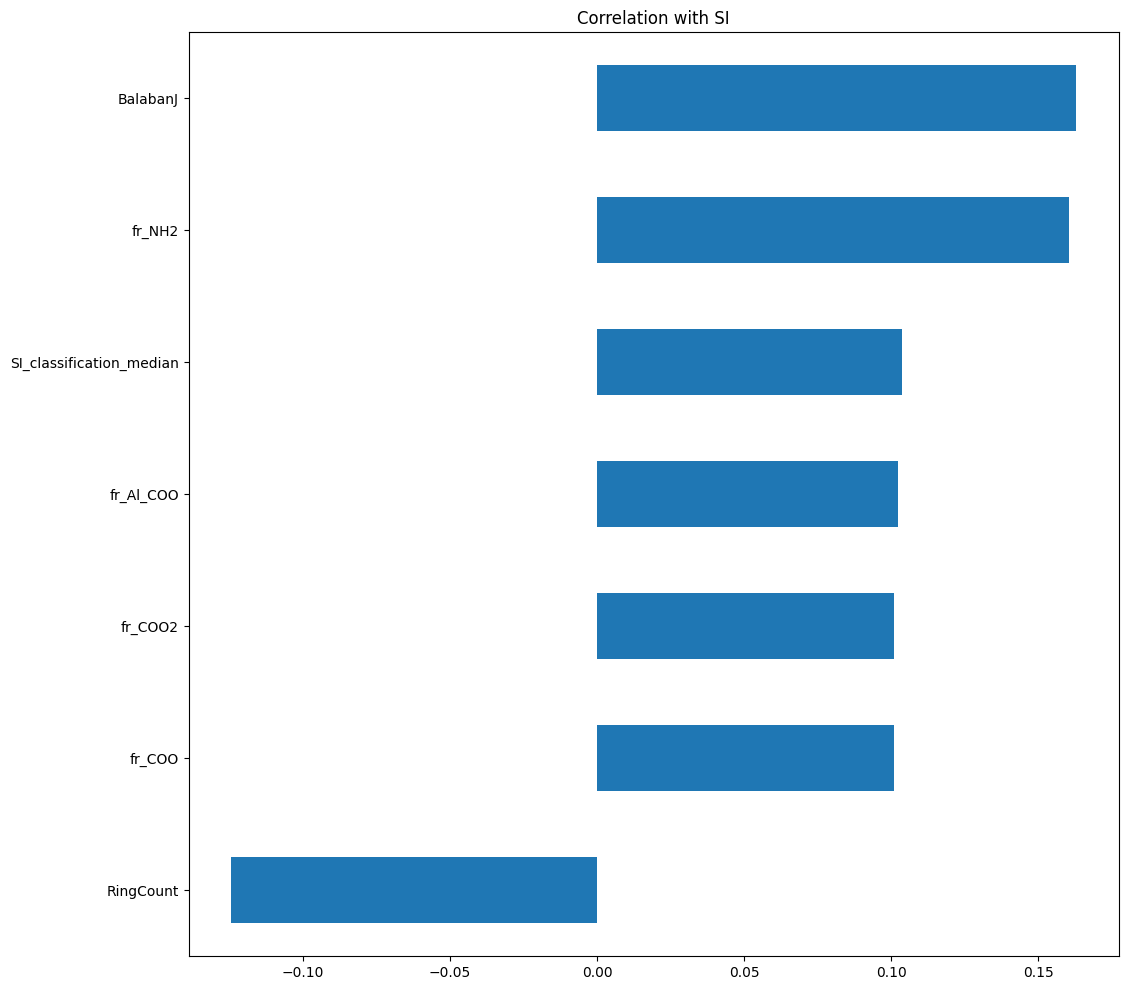

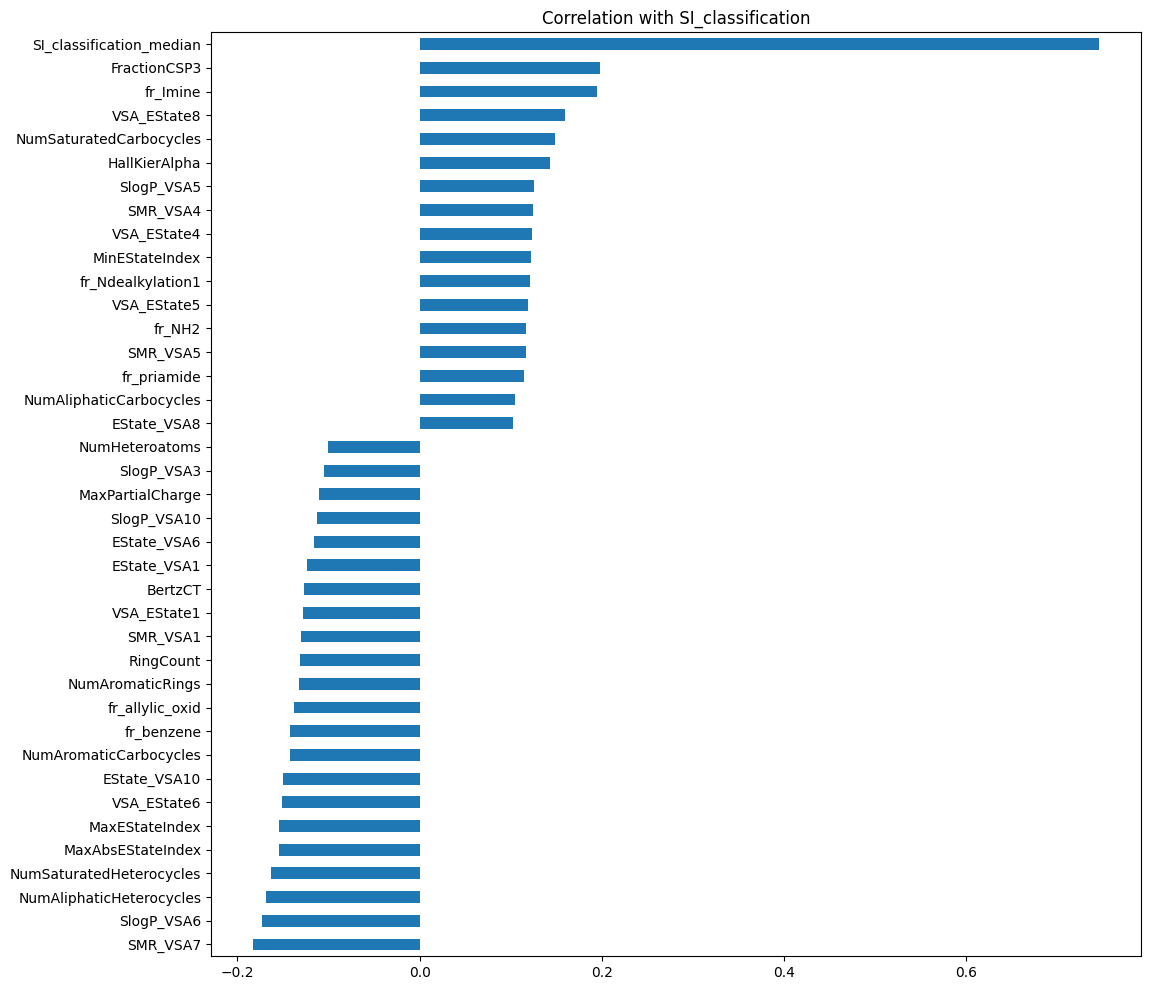

In [23]:
def plot_corr_with_target(df, target,min_corr_value):
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification']
    corr_target = df.corr(numeric_only=True)[target].drop(targets)
    corr_target = corr_target[(corr_target>=min_corr_value)|((corr_target<=-min_corr_value))]


    corr_target.sort_values().plot(kind='barh', figsize=(12,12))
    plt.title(f"Correlation with {target}")
    plt.show()


targets = ['CC50, mM','CC50_classification','IC50, mM','IC50_classification','SI','SI_classification']
min_corr_value = 0.1
for target in targets:
    plot_corr_with_target(df, target, min_corr_value)

## Взаимная информация

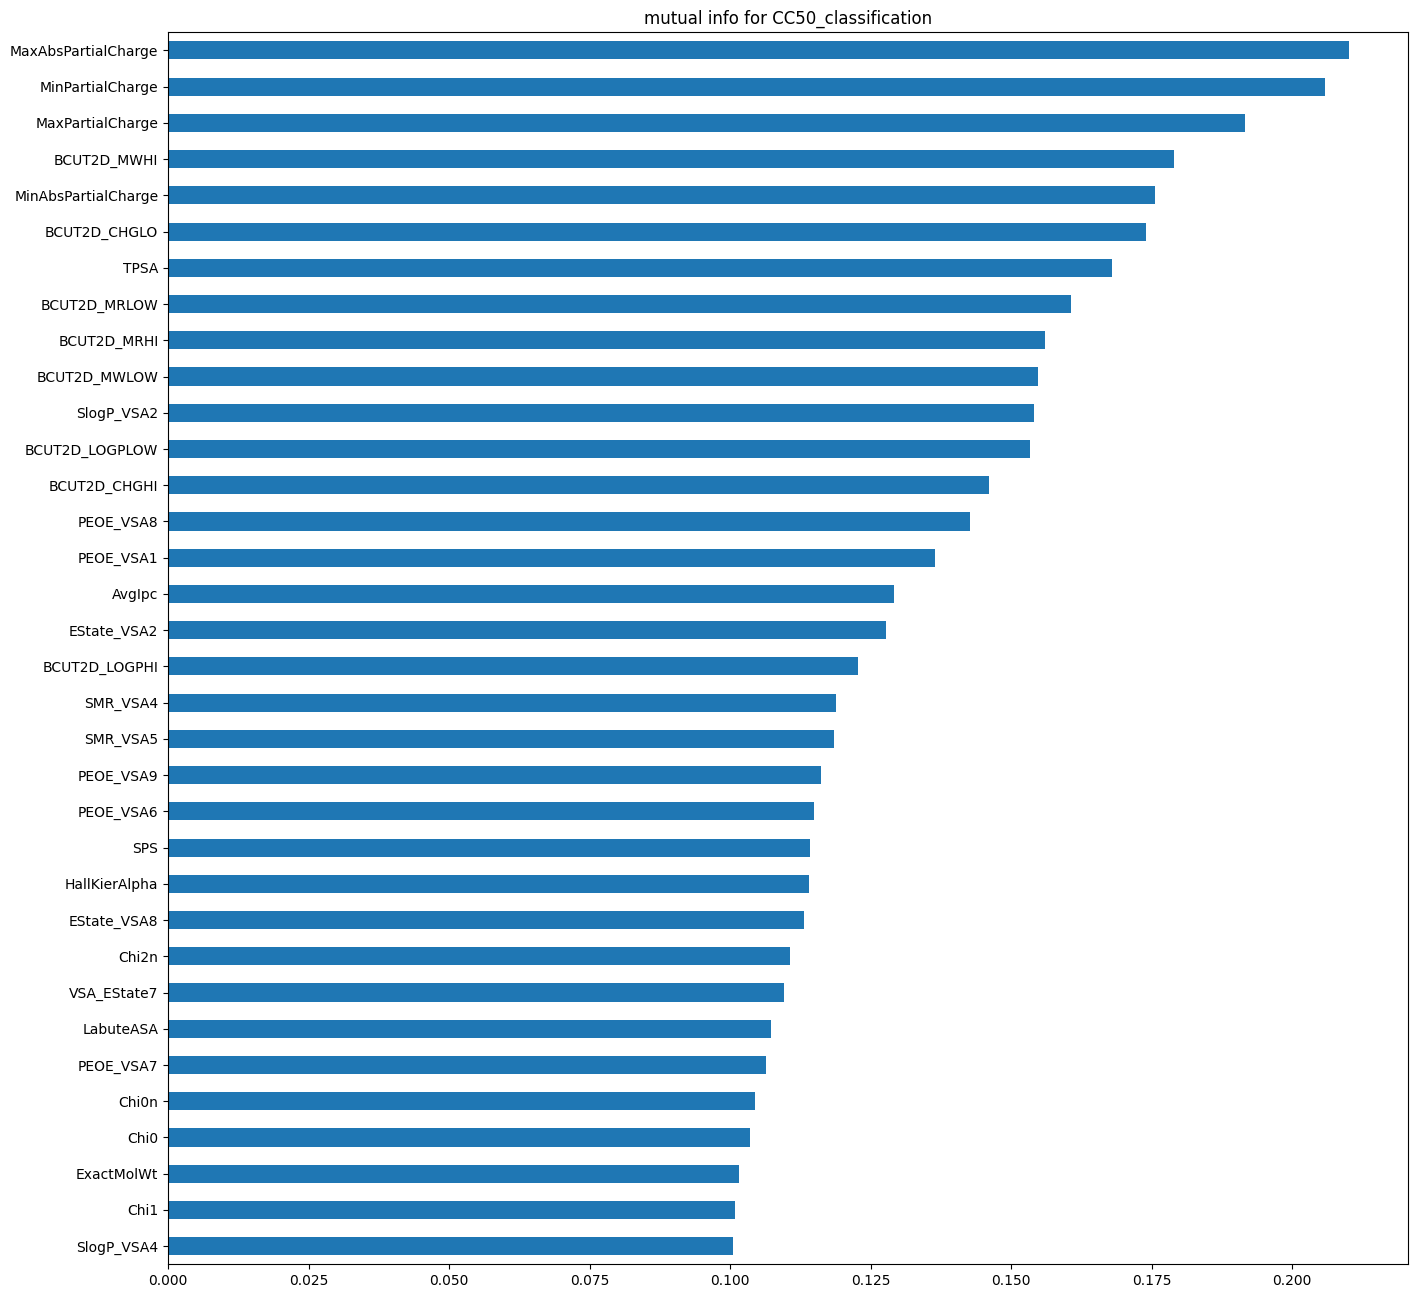

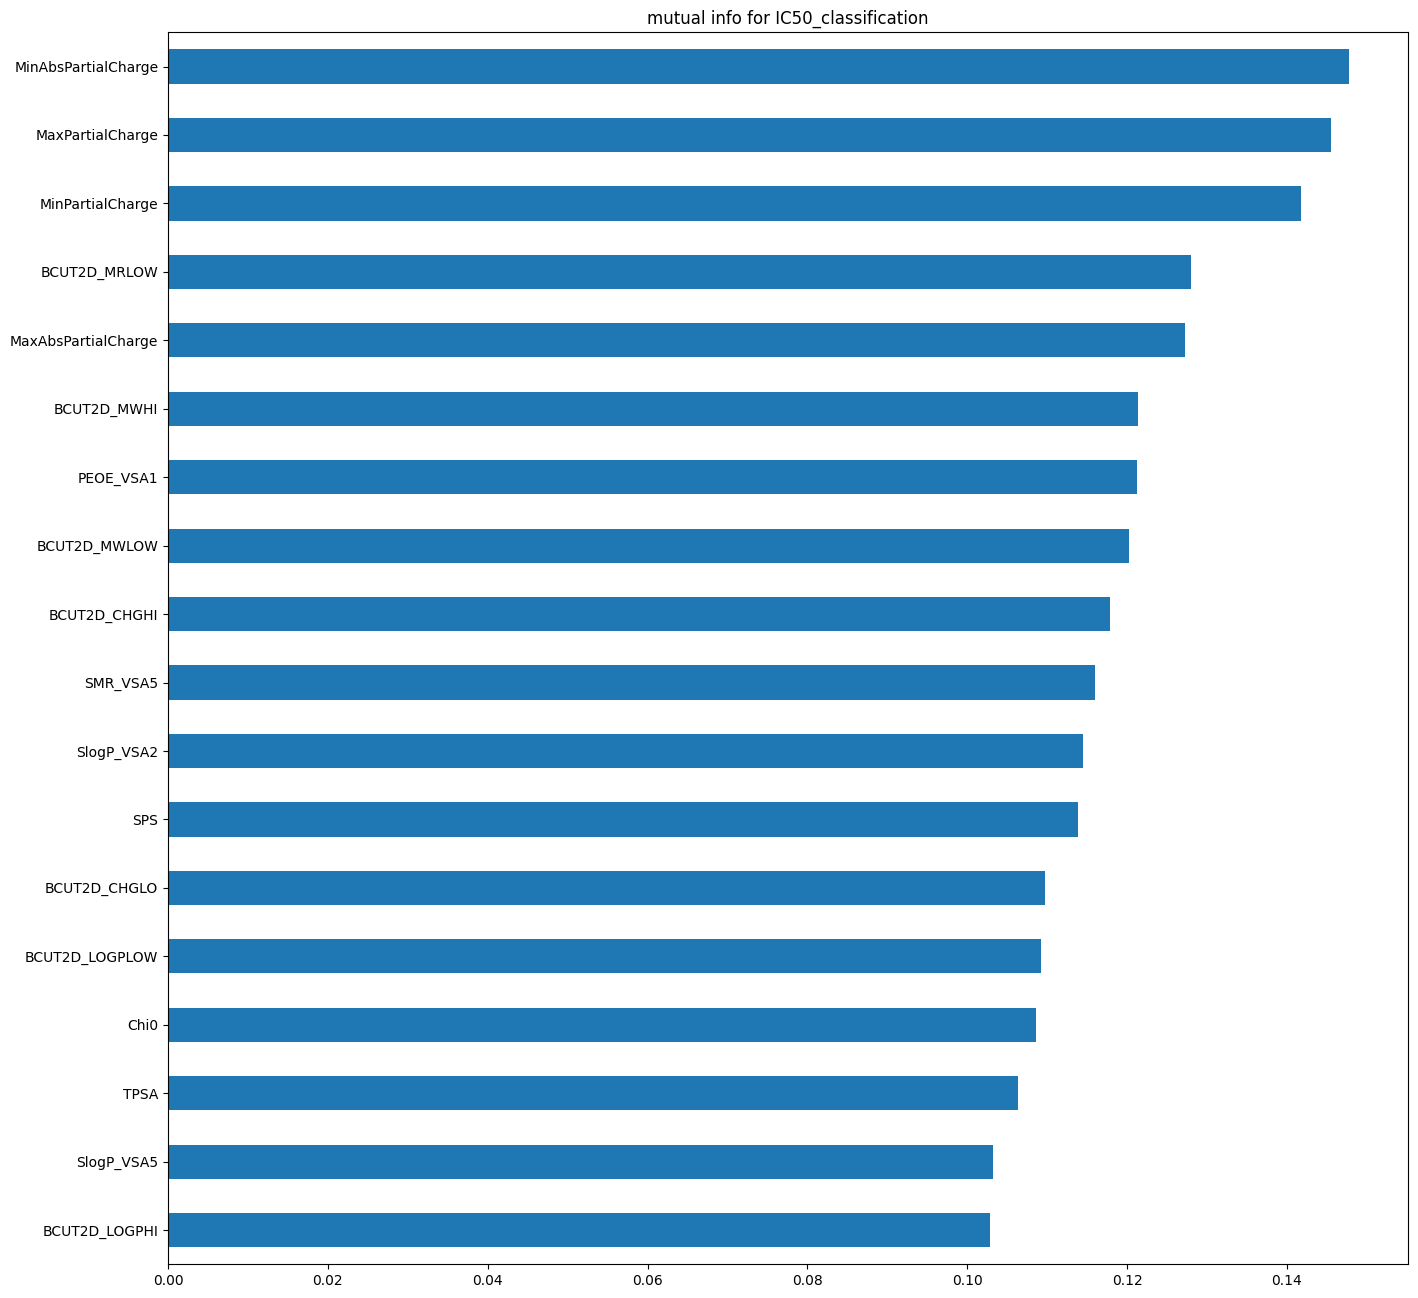

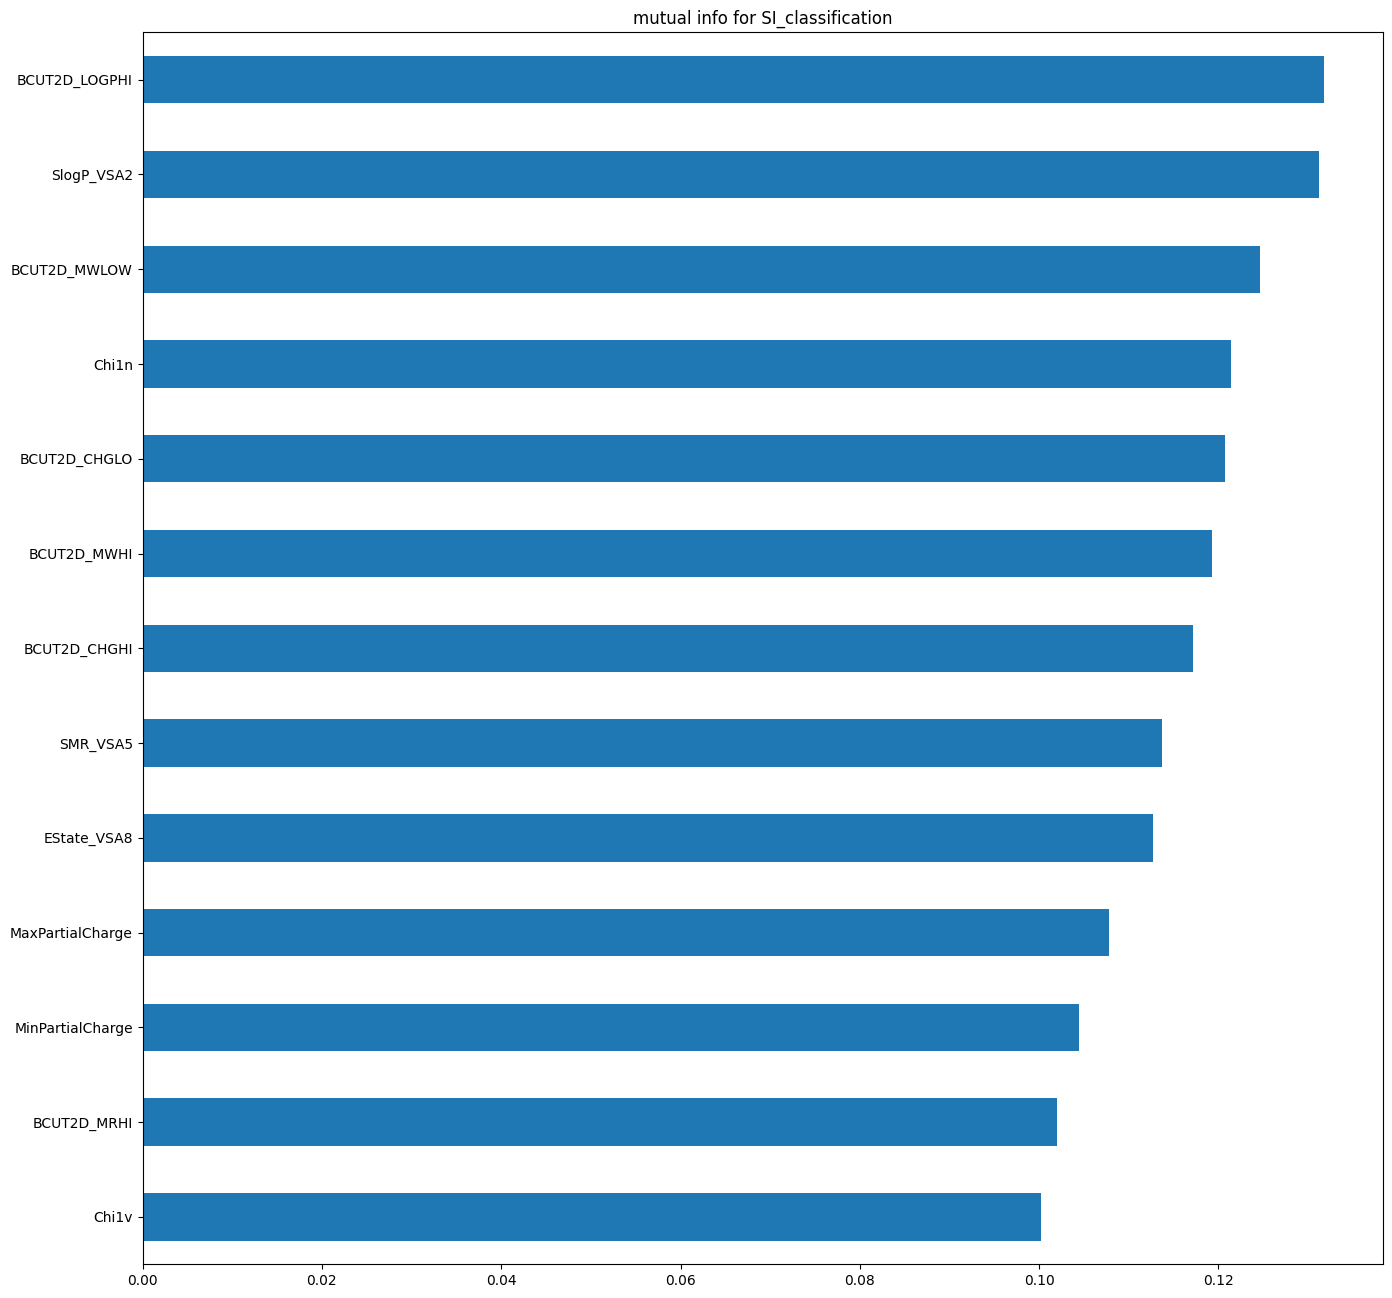

In [24]:
def plot_mutual_info_classif(df, target,threshold ,need_plot):  
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification','SI_classification_median']
    X = df.dropna().drop(columns=targets)
    y = df.dropna()[target]

    importances = mutual_info_classif(X, y)

    feature_importances = pd.Series(importances, X.columns[0:len(X.columns)])
    feature_importances_sorted = feature_importances.sort_values()
    important_features = feature_importances_sorted[feature_importances_sorted >= threshold]
    if need_plot:
        plt.figure(figsize=(16,16))
        important_features.plot(kind='barh')

        plt.title(f"mutual info for {target}")
        plt.show()
    
    return important_features.index

targets = ['CC50_classification','IC50_classification','SI_classification']

threshold = 0.1
mutual_info_classification_features_dict = {}
for target in targets:
    mutual_info_classification_features_dict[target] = plot_mutual_info_classif(df, target,threshold,True)


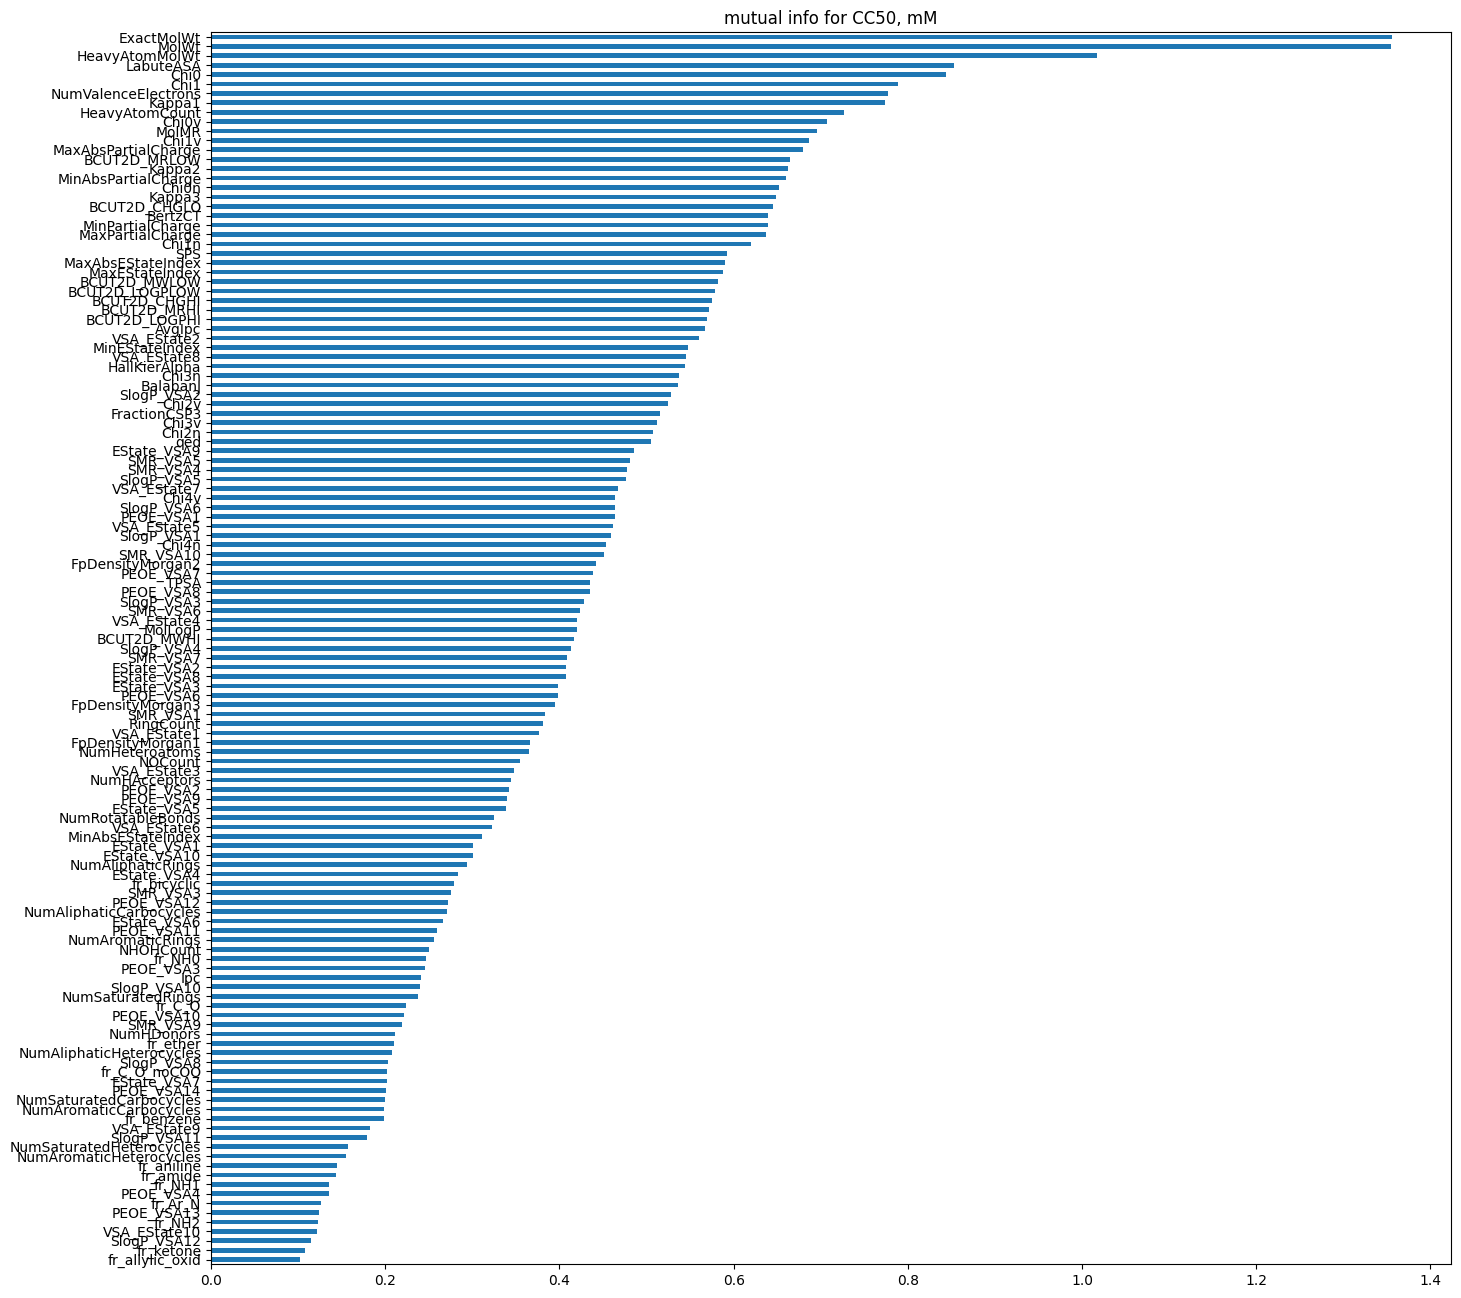

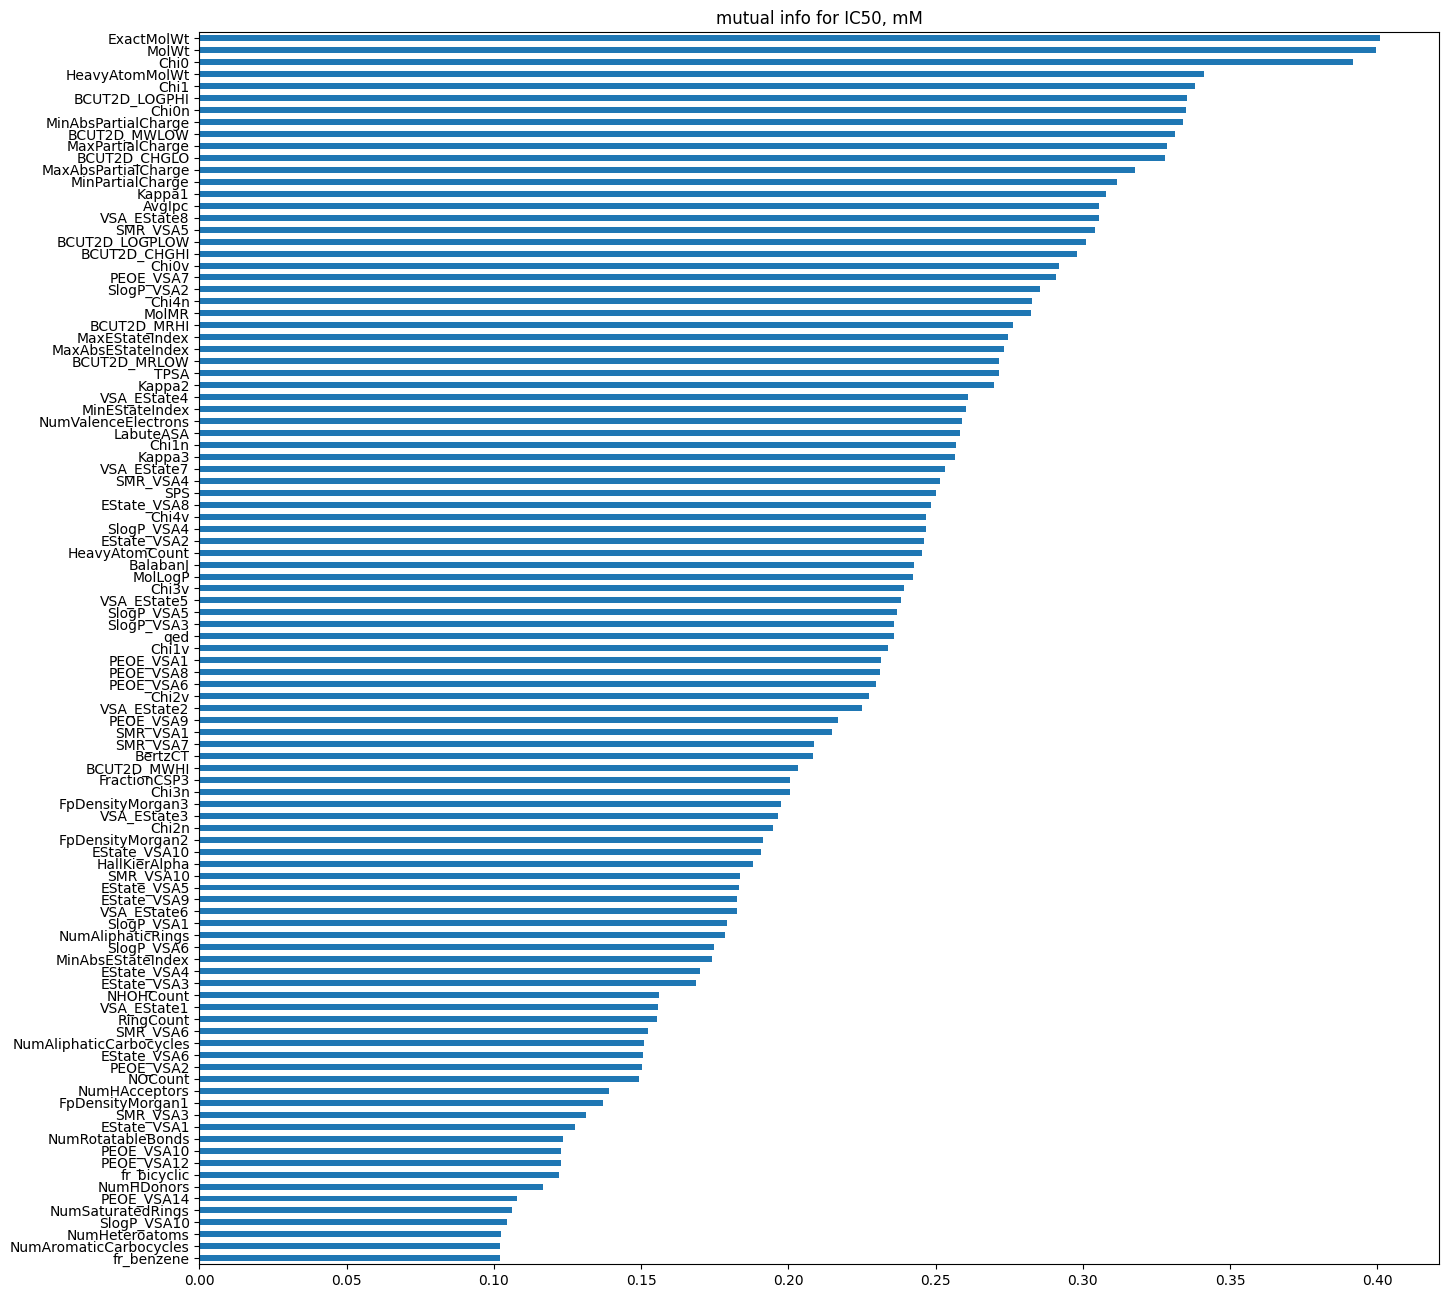

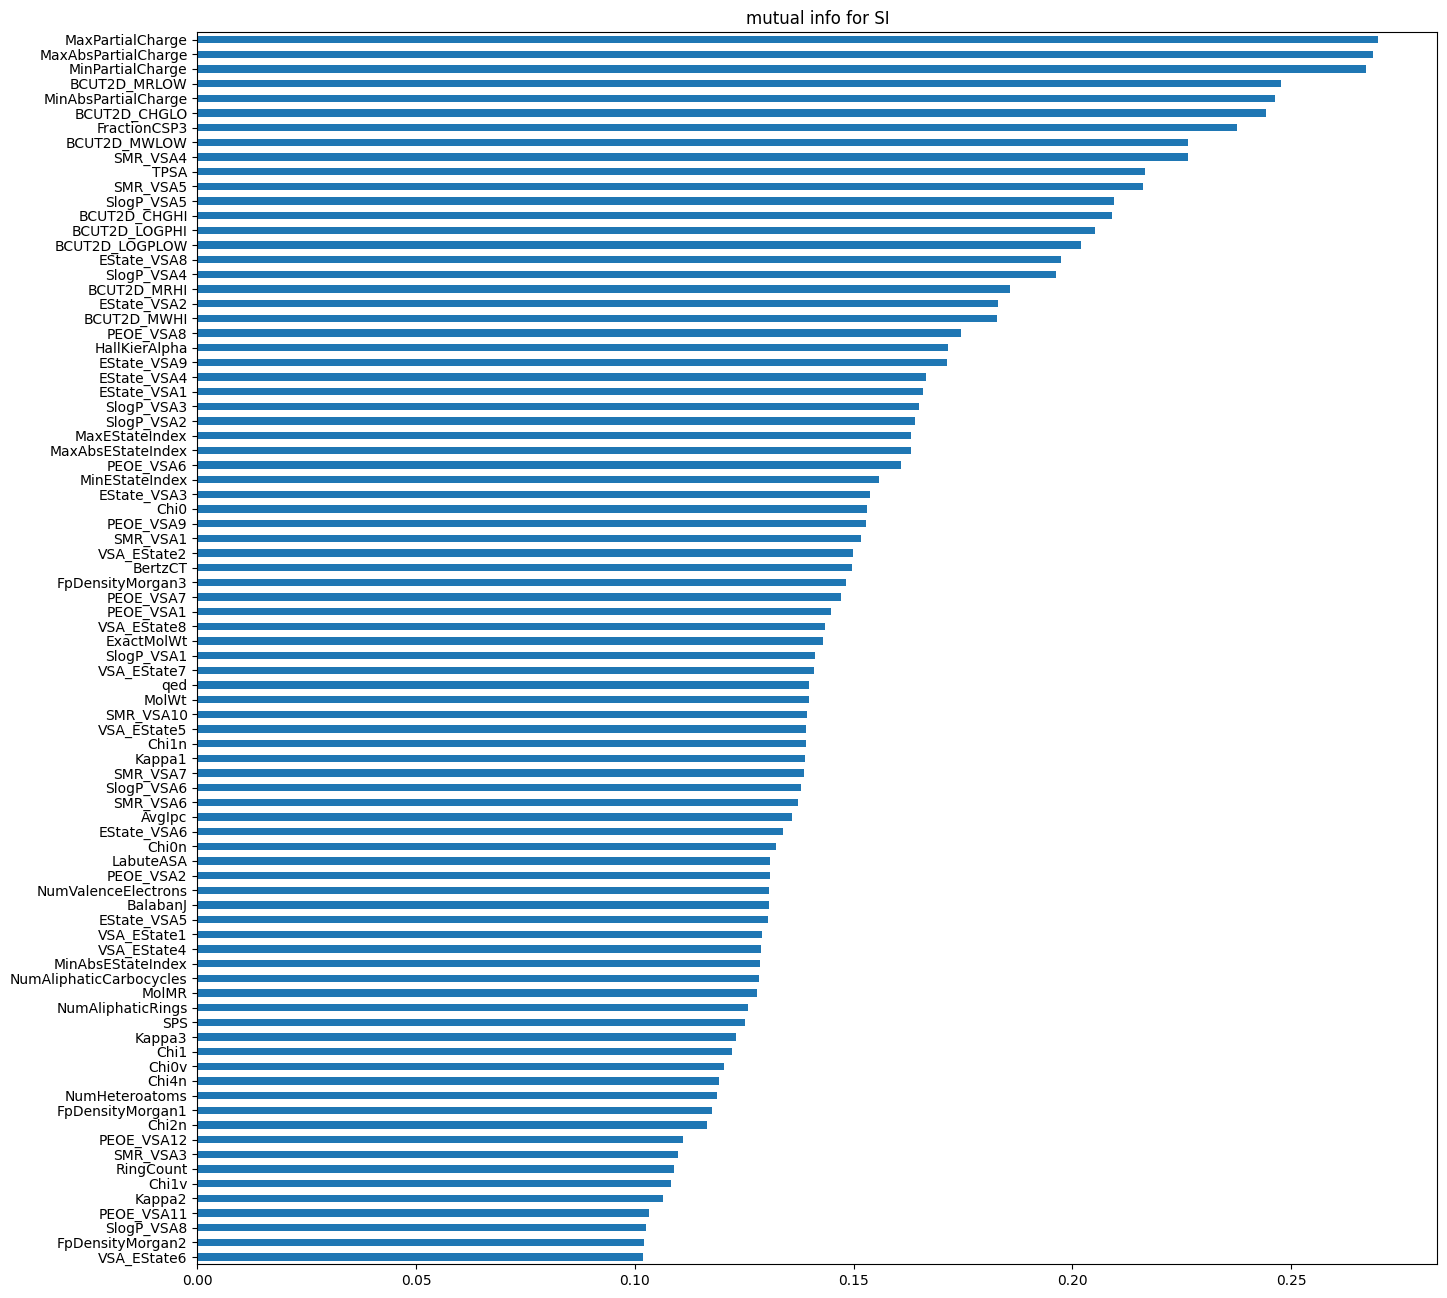

In [25]:
def plot_mutual_info_regression(df, target, threshold, need_plot):  
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification','SI_classification_median']
    X = df.dropna().drop(columns=targets)
    y = df.dropna()[target]

    importances = mutual_info_regression(X, y)

    feature_importances = pd.Series(importances, X.columns[0:len(X.columns)])
    feature_importances_sorted = feature_importances.sort_values()
    important_features = feature_importances_sorted[feature_importances_sorted >= threshold]
    if need_plot:
        plt.figure(figsize=(16,16))
        important_features.plot(kind='barh')

        plt.title(f"mutual info for {target}")
        plt.show()
    
    return important_features.index


targets = ['CC50, mM','IC50, mM','SI']
threshold = 0.1
mutual_info_regression_features_dict = {}
for target in targets:
    mutual_info_regression_features_dict[target] = plot_mutual_info_regression(df, target,threshold,True)

## Оценка с помощью алгоритмов машинного обучения
### Классификация

Поиск для CC50_classification.


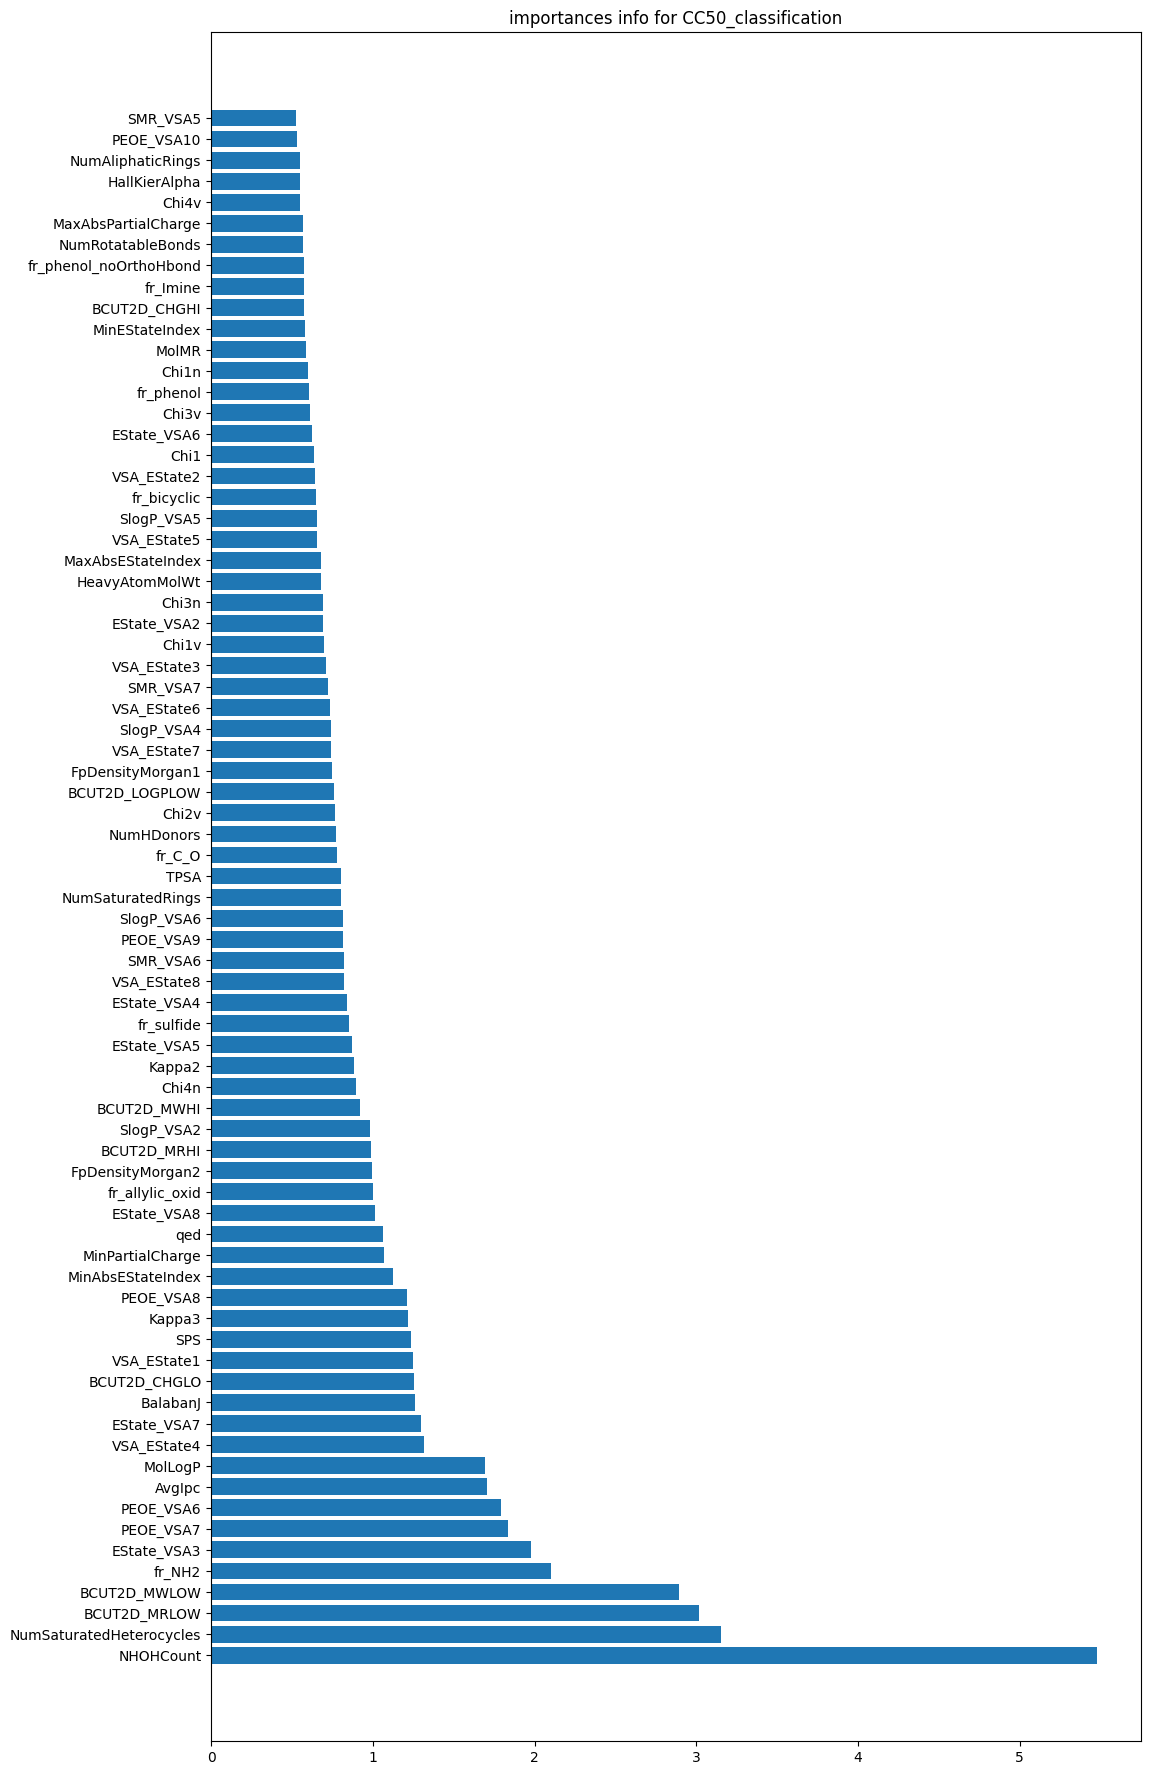

Поиск для IC50_classification.


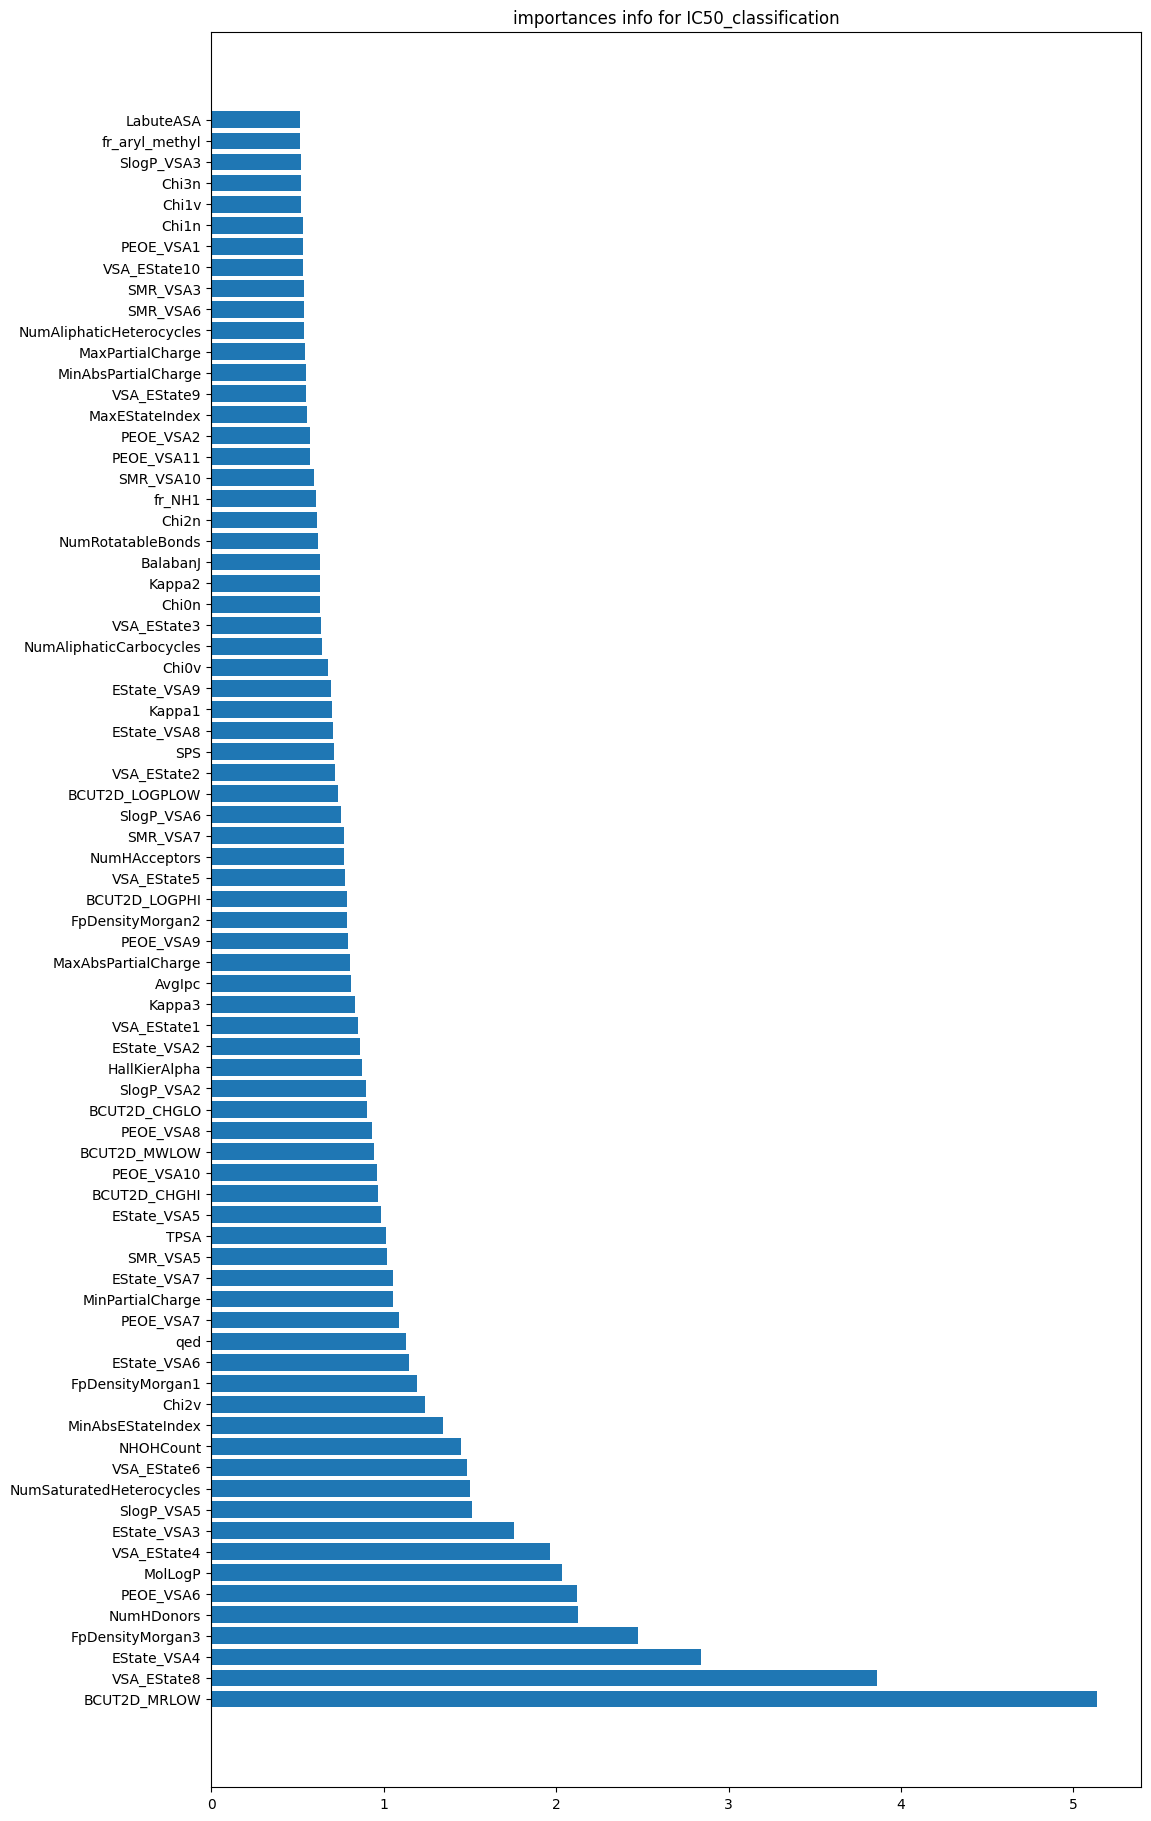

Поиск для SI_classification.


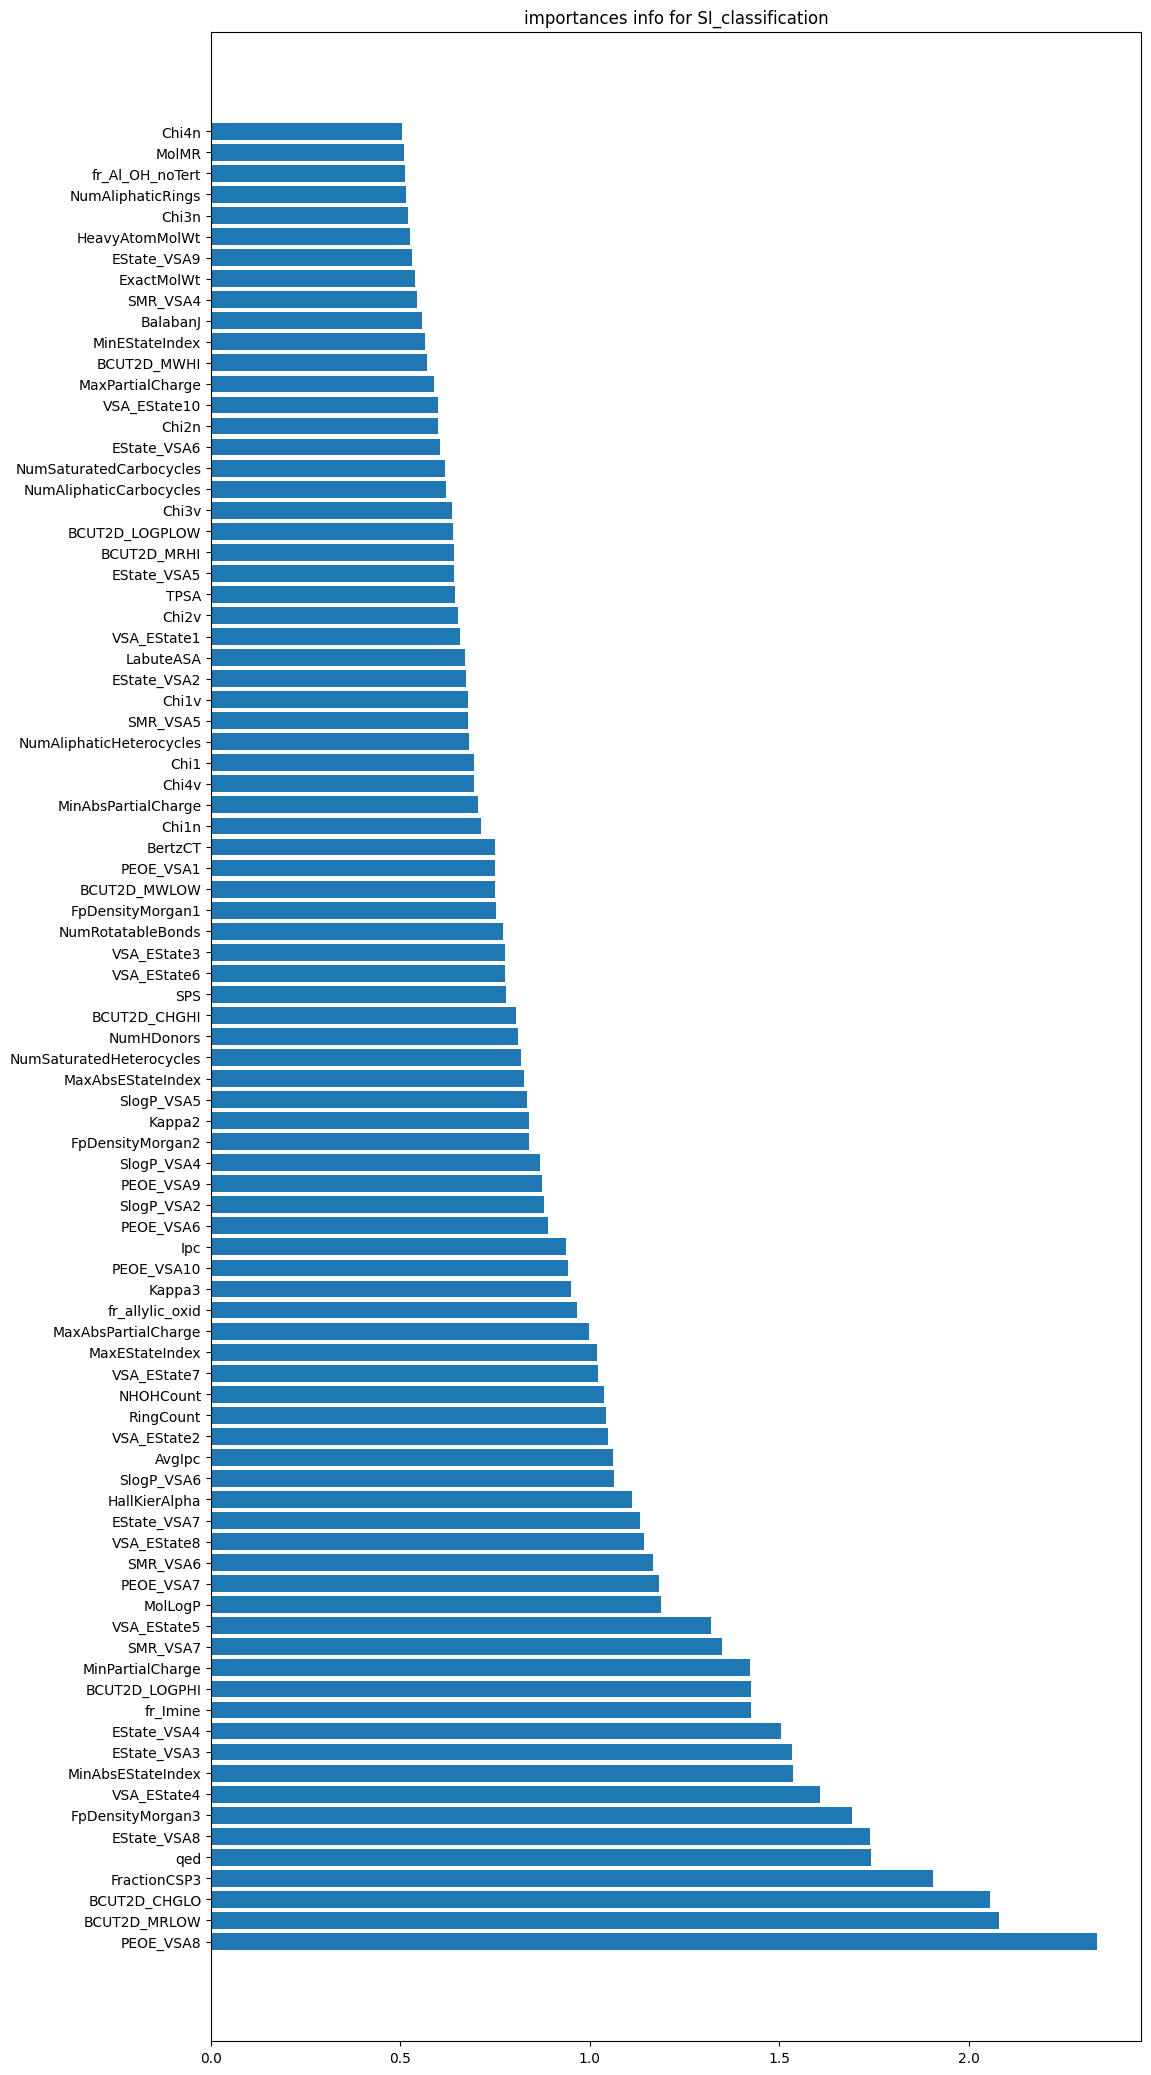

Поиск для SI_classification_median.


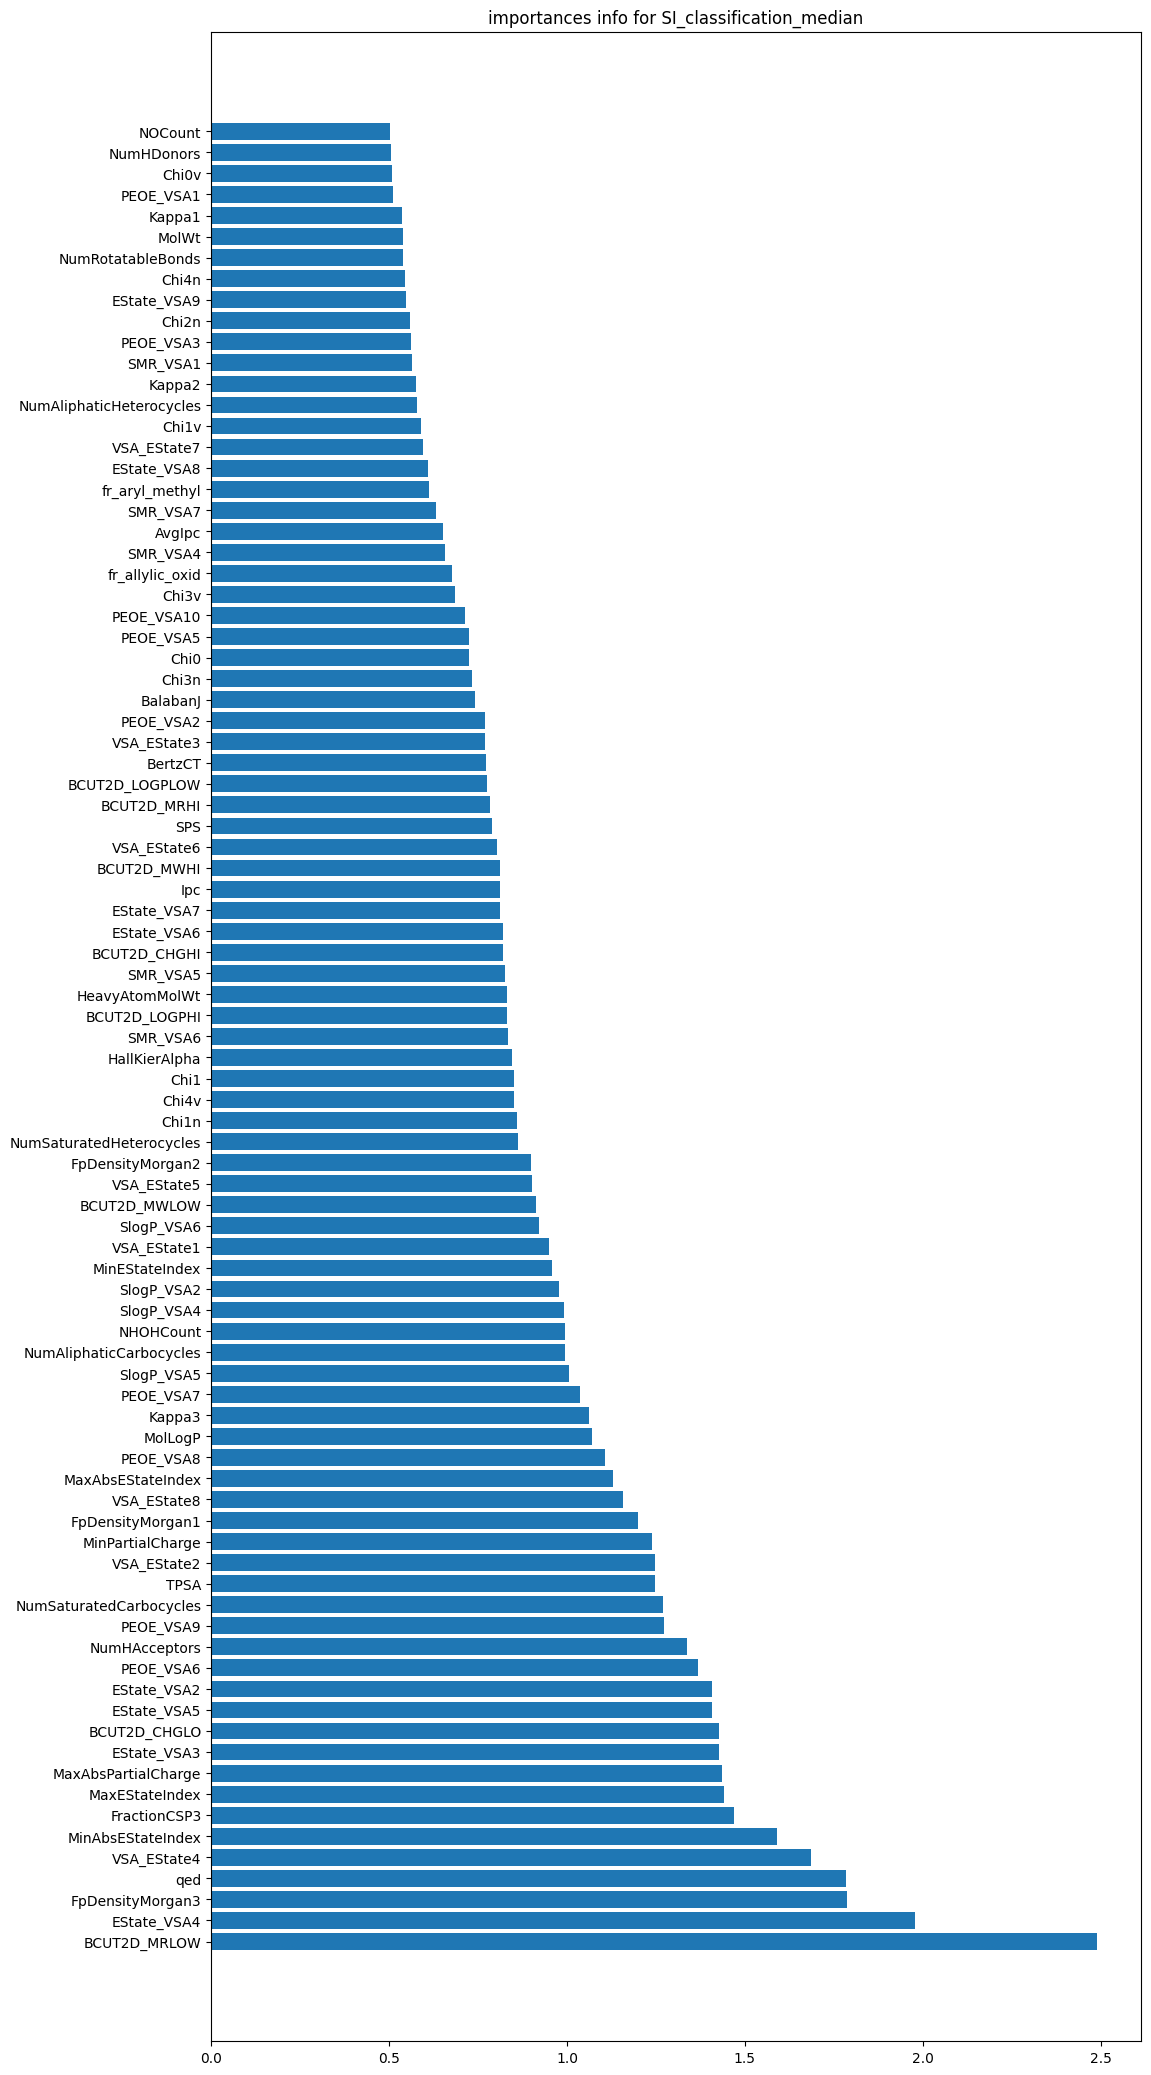

In [26]:
def catboost_clas_features(df, target,need_plot):
    print(f'Поиск для {target}.')
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification','SI_classification_median']
    X = df.copy().drop(columns=(targets))
    y = df[target]


    model = CatBoostClassifier(verbose=0, random_seed=42)
    model.fit(X, y)


    # Посмотрим на feature importance с помощью встроенного метода
    importances = model.get_feature_importance(prettified=True)
    importances = importances[importances['Importances']>=0.5]

    if need_plot:
        plt.figure(figsize=(12, max(6, len(importances) * 0.3)))
        plt.barh(importances['Feature Id'], importances['Importances'])
        plt.title(f"importances info for {target}")
        plt.show()

    return list(importances['Feature Id'])

targets = ['CC50_classification','IC50_classification','SI_classification', 'SI_classification_median']
classification_features_dict = {}
for target in targets:
    classification_features_dict[target]=catboost_clas_features(df, target,True)


### Регрессия

Поиск для CC50, mM.


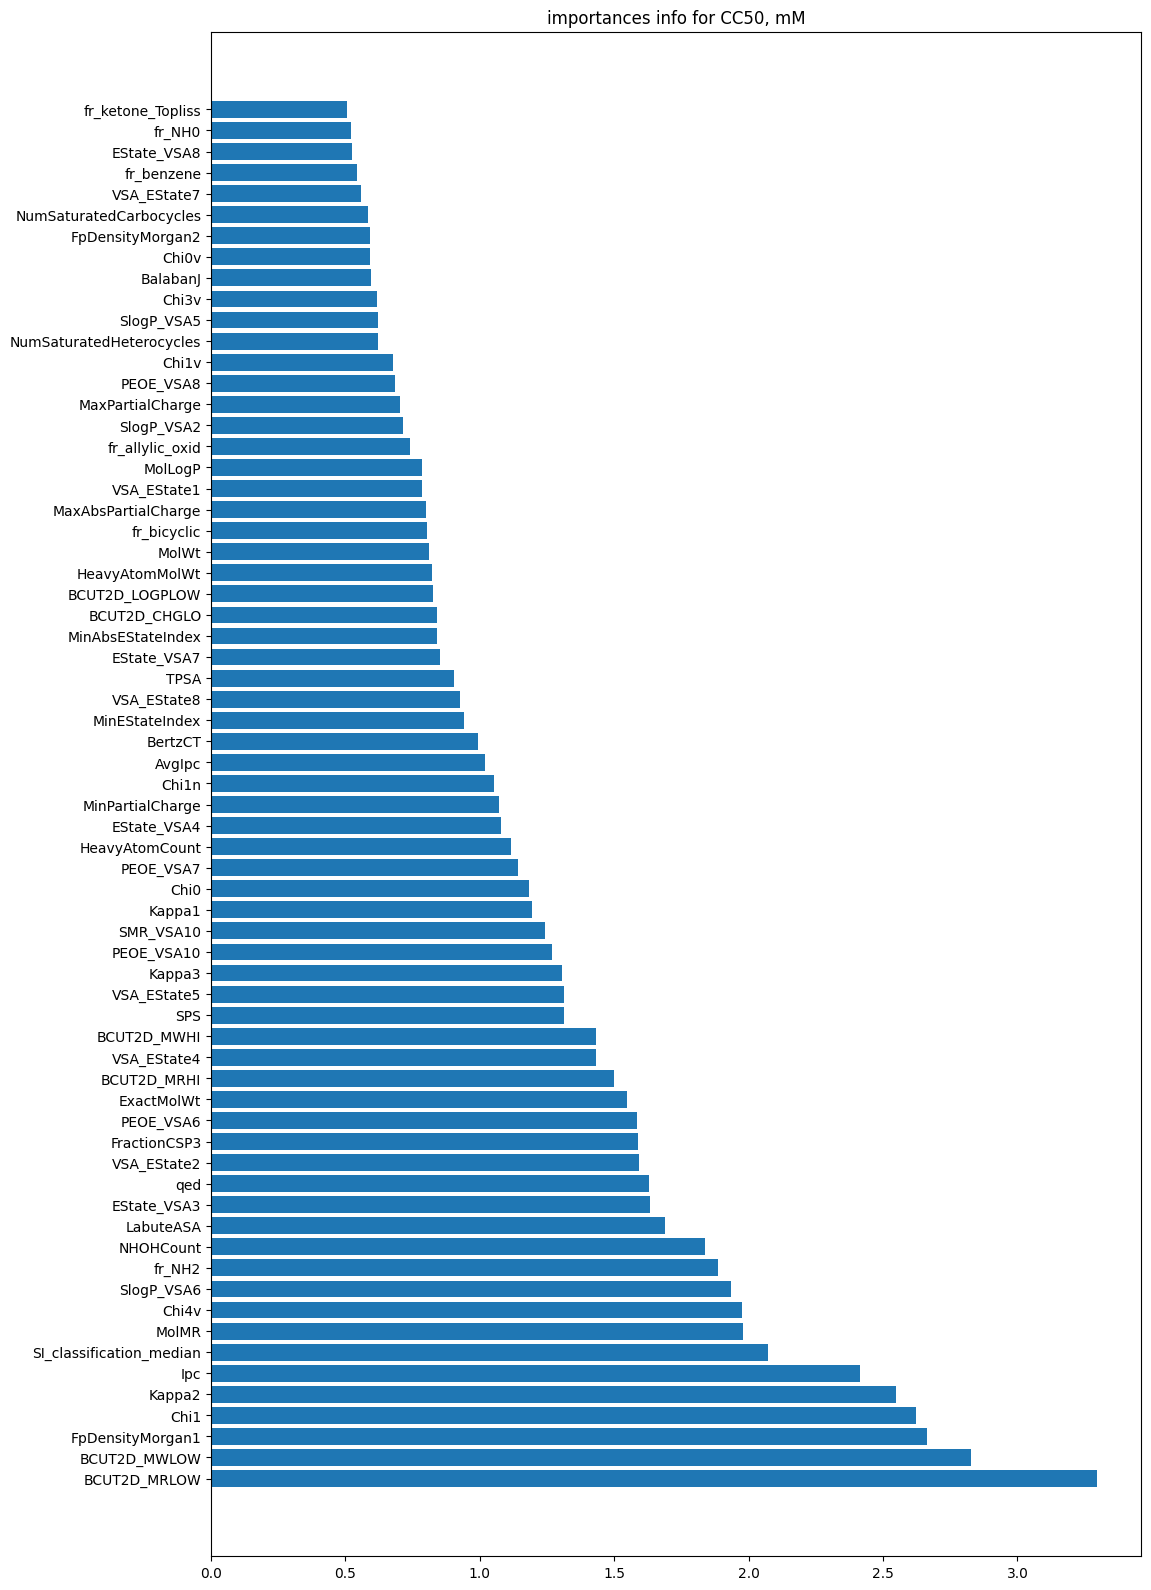

Поиск для IC50, mM.


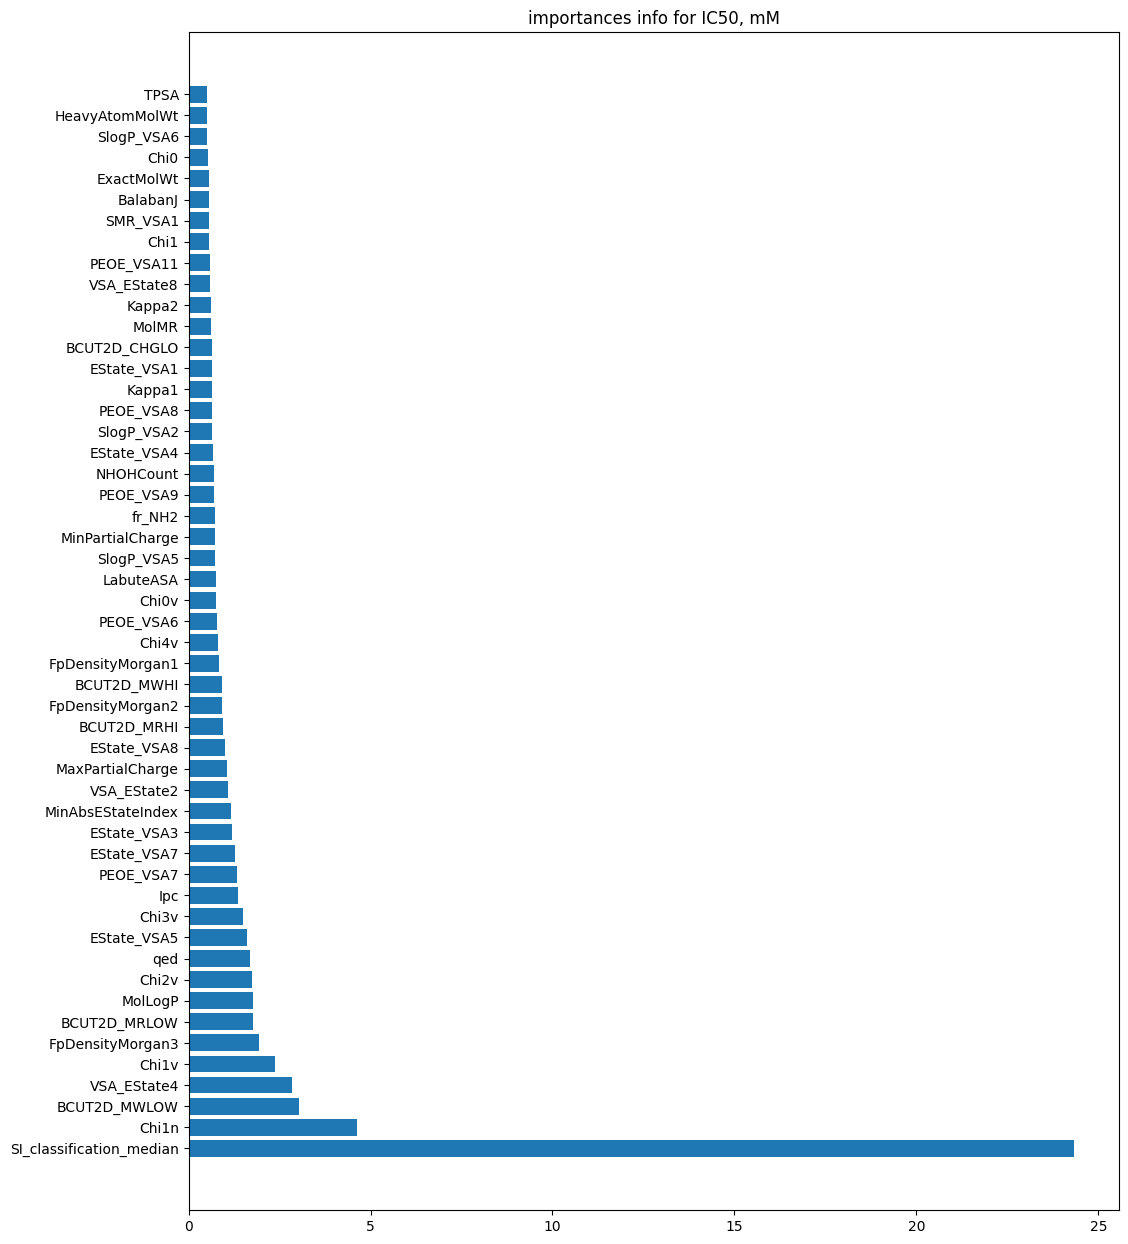

Поиск для SI.


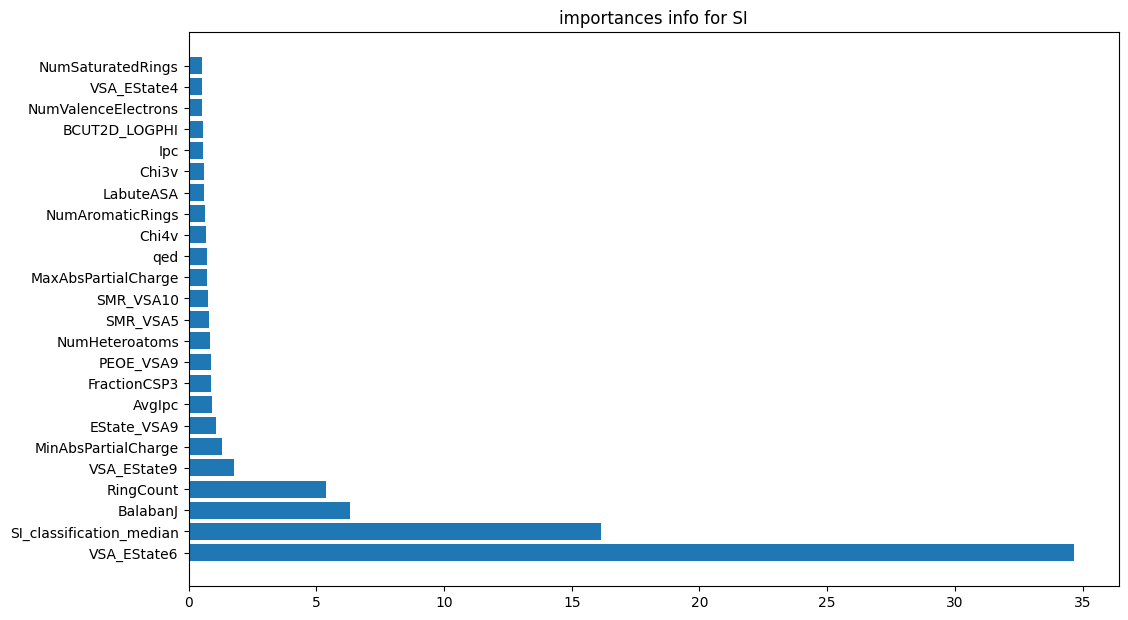

In [27]:
def catboost_reg_features(df, target,need_plot):
    print(f'Поиск для {target}.')
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification']
    X = df.copy().drop(columns=(targets))
    y = df[target]


    model = CatBoostRegressor(verbose=0, random_seed=42)
    model.fit(X, y)


    # Посмотрим на feature importance с помощью встроенного метода
    importances = model.get_feature_importance(prettified=True)
    importances = importances[importances['Importances']>=0.5]

    if need_plot:
        plt.figure(figsize=(12, max(6, len(importances) * 0.3)))
        plt.barh(importances['Feature Id'], importances['Importances'])
        plt.title(f"importances info for {target}")
        plt.show()

    return list(importances['Feature Id'])

targets = ['CC50, mM','IC50, mM','SI']
catboost_reg_features_dict = {}
for target in targets:
    catboost_reg_features_dict[target]=catboost_reg_features(df, target,True)

## Выводы по исследовательскому анализу данных
Массив данных содержит пропуски, часть столбцов не содержат полезной информации , есть выбросы и  высококоррелирующие признаки. Перед обучением моделей мы должны заполнить пропуски, масштабировать признаки, удалить лишние признаки. 